**Name: Jonathan Leong**         
**CLass: PE01**         
**Admin Number: 2401458A**

# **Musical Instruments Convolutional Neural Network (CNN)** # 

## **1. Introduction:** ##

**For my project, I am tasked to build a Convolutional Neural Network (CNN) to predict at least four different types of musical instruments. For this project, I am using two different dataset sources, both from Kaggle and combining them into one dataset with the different types of musical instruments, which I want to use in this project, to populate my training, testing and validation subfolders.**

**For this project, I'll be using the following 5 musical instruments: Drum, Guitar, Violin, Saxophone, and Piano. I used these musical instruments as they are one of the most commonly seen and played in the orchestra.**

**When I found my first public dataset source to use for this project, I realised that for a single class/category, such as saxophone, I only have about 160 images, which I felt wasn't enough images for training, testing, and validation. Hence, I decided to source out another public dataset to supplement what I have currently with additional images. I wanted more images as I felt that it would allow my model to perform better.**

# **The Setup Process:** #

## **2. Processing the data to prepare for the CNN model to use**

**Importing all the necessary libraries at the start**

In [253]:
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

#The following libraries are for reading the dataset:
import numpy as np
import pandas as pd

#For processing the images
import tensorflow as tf
import pathlib
from sklearn import preprocessing
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from PIL import Image
import os
import sys

from tensorflow.keras import layers, Model

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

#Used for plotting graphs:
import matplotlib.pyplot as plt
import seaborn as sns

#For Image Classification API services with trained model
import flask
from flask import Flask, jsonify, request, render_template
from werkzeug.serving import run_simple
import base64

#for pretrained models:
from tensorflow.keras.applications import MobileNetV3Small

from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications import efficientnet_v2
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from tensorflow.keras.applications import VGG16

from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input


#For seeing the accuracy performance of the trained model
import sklearn.metrics as metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, mean_squared_error, r2_score
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split


from scipy import stats
import io

**Resizing all the images in the dataset to make all the images the same size and save it in a new file location for the future use of pre-trained models**

In [130]:
#Resize all the images:
target_size =(224, 224)

#Original File Path:
org_img_folder = './dataset/musical_instruments'

#New File Path:
resized_img_folder = './dataset/resized_images'

#Making of the new File Path Directories
os.makedirs(resized_img_folder, exist_ok=True)

#Processing and resizing of all the images to use for the pre-trained models in the future
for root, dirs, files in os.walk(org_img_folder):
    relative_path = os.path.relpath(root, org_img_folder)
    save_dir = os.path.join(resized_img_folder, relative_path)
    os.makedirs(save_dir, exist_ok=True)
    
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(root, file)
            img = Image.open(img_path).convert('RGB')
            img_resized = img.resize(target_size)
            img_resized.save(os.path.join(save_dir, file))

**Basic Image augmentation, I first conducted this basic image orientation taught in the labs to do this project, to discover which of my trained models will the best without much variable complexity:**

In [249]:
#ImageDataGenerator with augmentation setting
batch_size=32

#folder paths
Training_data = './dataset/resized_images/training'
Validation_data = './dataset/resized_images/validation'
Testing_data = './dataset/resized_images/testing'

# this is the augmentation configuration 
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator( rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip= True)

train_generator = train_datagen.flow_from_directory(Training_data, target_size=target_size, batch_size=batch_size, class_mode='categorical')

# this is the augmentation configuration 
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
validation_generator = test_datagen.flow_from_directory(Validation_data, target_size=target_size, batch_size=batch_size, class_mode='categorical', shuffle="False")

Found 2344 images belonging to 5 classes.
Found 625 images belonging to 5 classes.


**Getting the labels to use for image classification and accuracy testing later.**

In [132]:
labels = (train_generator.class_indices)
labels = dict((v,k) for k,v in labels.items())
print(labels)

class_labels = sorted(train_generator.class_indices.keys())
num_classes = len(class_labels) 
print(f"There are {num_classes} Classes: {class_labels}")

{0: 'drums', 1: 'guitar', 2: 'piano', 3: 'saxaphone', 4: 'violin'}
There are 5 Classes: ['drums', 'guitar', 'piano', 'saxaphone', 'violin']


**Make a directory to store all future models:**

In [133]:
os.makedirs('./models', exist_ok=True)

## **3. Dataset Audit:** ##
**I decided to audit my dataset to check if my dataset for both my validation and training have any imbalances.**


Image Counts per Category (Training Set):
drums: 444
guitar: 475
piano: 475
saxaphone: 475
violin: 475


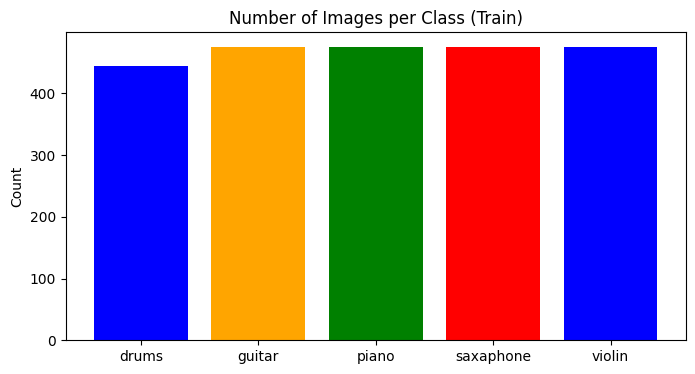

In [134]:
#Create a dictionary to store the count of images for each class in the training folder
training_count = {}

# loop through each class and count the number of files
for category in class_labels:
    Folder_Path_Train = os.path.join(Training_data, category)
    num_images = len(os.listdir(Folder_Path_Train))
    training_count[category] = num_images

# display the results
print("\nImage Counts per Category (Training Set):")
for category, count in training_count.items():
    print(f"{category}: {count}")

# visualize with a bar chart
plt.figure(figsize=(8, 4))
plt.bar(training_count.keys(), training_count.values(), color=['blue', 'orange', 'green', 'red'])
plt.title('Number of Images per Class (Train)')
plt.ylabel('Count')
plt.show()


Image Counts per Category (Validation Set):
drums: 125
guitar: 125
piano: 125
saxaphone: 125
violin: 125


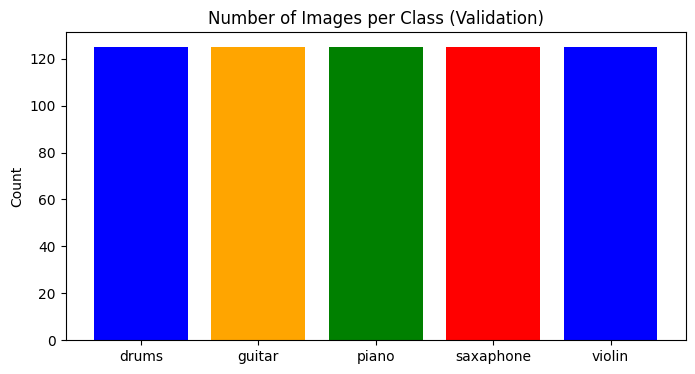

In [135]:
#Create a dictionary to store the count of images for each class in the validation folder
validation_count = {}

# loop through each class and count the number of files
for category in class_labels:
    Folder_Path_Valid = os.path.join(Validation_data, category)
    num_images = len(os.listdir(Folder_Path_Valid))
    validation_count[category] = num_images

# display the results
print("\nImage Counts per Category (Validation Set):")
for category, count in validation_count.items():
    print(f"{category}: {count}")

# visualize with a bar chart
plt.figure(figsize=(8, 4))
plt.bar(validation_count.keys(), validation_count.values(), color=['blue', 'orange', 'green', 'red'])
plt.title('Number of Images per Class (Validation)')
plt.ylabel('Count')
plt.show()

**The only slight imbalance in my training dataset, with the class with the most images (Piano) having 559 images and the class with the least images (drums) having only 519 images. As the imbalance in the training dataset is only 6.95%, and the percentage of overall drum images is 19.16% when the total amount of images from the training and validation set is added together, the imbalance is insignificant**

# **Use of Trained CNN Models**

## **4.1. First Model Test** ##
**For my very first model testing, I decided to use the basic model from Lab 13 to try and get a baseline understanding of how well my model will perform without any advanced image augmentation and any advanced models being used. Additionally, I decided to try out 250 epochs to get a gauge of how well my future models will perform and what point I should stop my epochs or set my epochs as the maximum epochs to prevent overfitting from happening in my models.**

In [136]:
#Creating the model:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(224, 224, 3)))
model.add(layers.Conv2D(16, (3, 3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(5, activation="softmax"))
print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)                   │ (None, 224, 224, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 112, 112, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 112, 112, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 56, 56, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 56, 56, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_31 (Dropout)                 │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_40 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,226,373 (12.31 MB)

 Trainable params: 3,226,373 (12.31 MB)

 Non-trainable params: 0 (0.00 B)

None


In [137]:
model.compile(loss = "categorical_crossentropy", optimizer = "adam", metrics=["accuracy"])

In [138]:
history = model.fit(train_generator, validation_data=validation_generator, epochs=250, verbose=1)

Epoch 1/250
74/74 ━━━━━━━━━━━━━━━━━━━━ 24s 312ms/step - accuracy: 0.2871 - loss: 1.5827 - val_accuracy: 0.2896 - val_loss: 1.5355
Epoch 2/250
74/74 ━━━━━━━━━━━━━━━━━━━━ 13s 174ms/step - accuracy: 0.4155 - loss: 1.4152 - val_accuracy: 0.4224 - val_loss: 1.3628
Epoch 3/250
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 145ms/step - accuracy: 0.4953 - loss: 1.2623 - val_accuracy: 0.4400 - val_loss: 1.3541
Epoch 4/250
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.5469 - loss: 1.1807 - val_accuracy: 0.4592 - val_loss: 1.3207
Epoch 5/250
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.5683 - loss: 1.1341 - val_accuracy: 0.4848 - val_loss: 1.2582
Epoch 6/250
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.5990 - loss: 1.0720 - val_accuracy: 0.4304 - val_loss: 1.3401
Epoch 7/250
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.6011 - loss: 1.0259 - val_accuracy: 0.5008 - val_loss: 1.2794
Epoch 8/250
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - accuracy: 0.6254 - loss: 0.9759 - 

In [139]:
model.save("./models/musical_instruments_model.keras")
print("Model saved to disk")

Model saved to disk


In [140]:
# Evaluate the model
model = tf.keras.models.load_model("./models/musical_instruments_model.keras")

scores_val = model.evaluate(validation_generator, verbose=0)
print("Validation Accuracy: %.2f%%" % (scores_val[1]*100))

scores_train = model.evaluate(train_generator, verbose=0)
print("Train Accuracy: %.2f%%" % (scores_train[1]*100))

Validation Accuracy: 55.36%
Train Accuracy: 99.91%


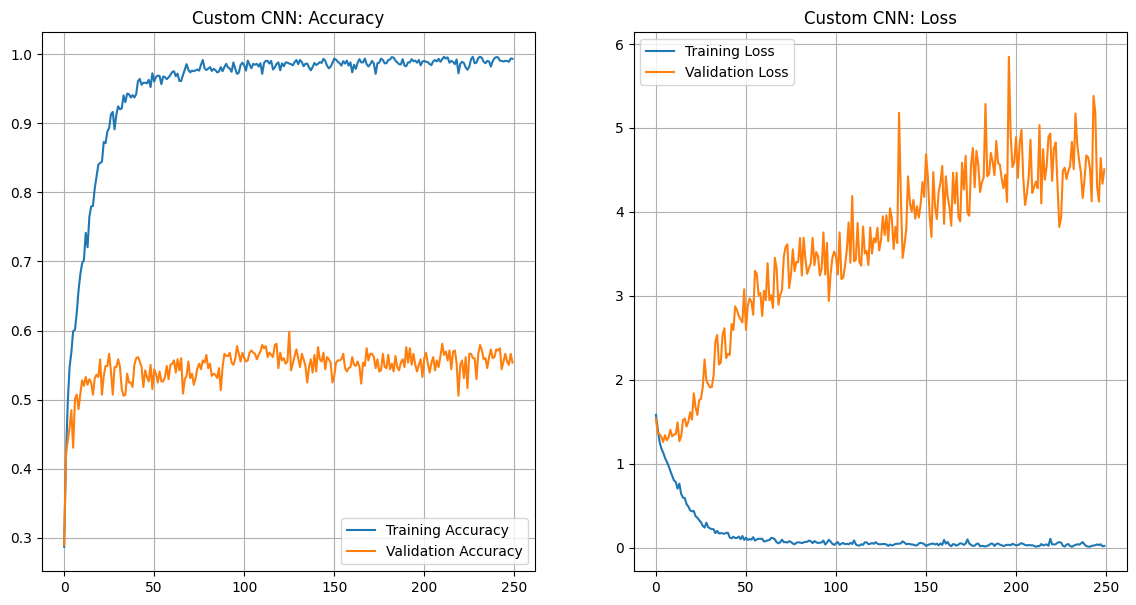

In [141]:
if history:
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 7))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Custom CNN: Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Custom CNN: Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

## **4.2. Insights from Model 1:**
**Just one glance at the chart above and the training of my First model, I can tell that it is clearly overfitted with a final Training Accuracy of 99.91% and Validation accuracy of 55.36%. At the 27th epochs, it has already hit the 90% mark for the training accuracy. As for the validation accuracy, it only reached a peak of 59.58% accuracy at the 126th epoch.**

**As for the training and validation loss for the First model, the training loss has dropped to around the range of 0.05 around the 100 epochs, whereas the validation loss for this model is constantly increasing to over 4 and it even reached the peak validation loss of 5.85 at the 198th epoch.**

**As my modely is clearly overfitted, I decided to continue training more models to find a more reasonable model with at least 70% accuracy and that of around high 80% accuracy to low 90% for both my Training and Validation Accuracy to ensure that my model is not overfitted.**

## **5.1. Testing of 2nd Model:** ##

**I decided to change the epochs of my new model to only 200 epochs, as 250 epochs were taking too long, and I feel that 200 is more than enough to train my model. I am making the epochs 200 and not 100 as I want to see how the model will perform at 200 first. The other change I am making to the new model is that I am using "valid" padding now instead of "same" padding**

In [142]:
#Creating the model:
model0 = tf.keras.models.Sequential()
model0.add(tf.keras.layers.Input(shape=(224, 224, 3)))
model0.add(layers.Conv2D(16, (3, 3), padding='valid', activation='relu'))
model0.add(layers.MaxPooling2D((2, 2)))
model0.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model0.add(layers.MaxPooling2D((2, 2)))
model0.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model0.add(layers.MaxPooling2D((2, 2)))
model0.add(tf.keras.layers.Dropout(0.2))
model0.add(tf.keras.layers.Flatten())
model0.add(tf.keras.layers.Dense(128, activation='relu'))
model0.add(tf.keras.layers.Dense(5, activation="softmax"))
print(model0.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)                   │ (None, 222, 222, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (None, 111, 111, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 109, 109, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ (None, 54, 54, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_20 (Conv2D)                   │ (None, 52, 52, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_20 (MaxPooling2D)      │ (None, 26, 26, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_32 (Dropout)                 │ (None, 26, 26, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 21632)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 128)                 │       2,769,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,784,005 (10.62 MB)

 Trainable params: 2,784,005 (10.62 MB)

 Non-trainable params: 0 (0.00 B)

None


In [143]:
model0.compile(loss = "categorical_crossentropy", optimizer = "adam", metrics=["accuracy"])

In [144]:
history0 = model0.fit(train_generator, validation_data=validation_generator, epochs=200, verbose=1)

Epoch 1/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 137ms/step - accuracy: 0.2760 - loss: 1.6350 - val_accuracy: 0.2688 - val_loss: 1.5699
Epoch 2/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - accuracy: 0.4181 - loss: 1.4249 - val_accuracy: 0.4256 - val_loss: 1.4148
Epoch 3/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 136ms/step - accuracy: 0.4629 - loss: 1.3297 - val_accuracy: 0.4128 - val_loss: 1.3825
Epoch 4/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 136ms/step - accuracy: 0.5102 - loss: 1.2372 - val_accuracy: 0.4384 - val_loss: 1.3763
Epoch 5/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - accuracy: 0.5324 - loss: 1.1780 - val_accuracy: 0.4272 - val_loss: 1.3684
Epoch 6/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 136ms/step - accuracy: 0.5653 - loss: 1.1313 - val_accuracy: 0.4944 - val_loss: 1.3284
Epoch 7/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - accuracy: 0.5934 - loss: 1.0650 - val_accuracy: 0.4960 - val_loss: 1.2585
Epoch 8/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 136ms/step - accuracy: 0.6096 - loss: 1.0201 - 

In [145]:
model0.save("./models/musical_instruments_model0.keras")
print("Model0 saved to disk")

Model0 saved to disk


In [146]:
# Evaluate the model
model0 = tf.keras.models.load_model("./models/musical_instruments_model0.keras")

scores0_val = model0.evaluate(validation_generator, verbose=0)
print("Validation Accuracy: %.2f%%" % (scores0_val[1]*100))

scores0_train = model0.evaluate(train_generator, verbose=0)
print("Train Accuracy: %.2f%%" % (scores0_train[1]*100))

Validation Accuracy: 55.20%
Train Accuracy: 99.45%


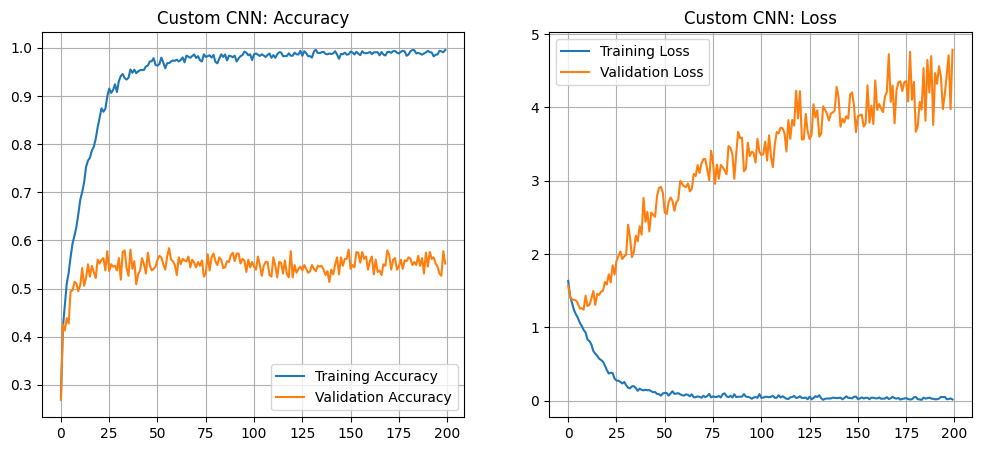

In [147]:
if history0:
    acc = history0.history['accuracy']
    val_acc = history0.history['val_accuracy']
    loss = history0.history['loss']
    val_loss = history0.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Custom CNN: Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Custom CNN: Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

## **5.2. Insights from Model 2:**
**Just one glance at the chart above and the training of my Second model, I can tell that it is still clearly overfitted with a final Training Accuracy of 99.45% and Validation accuracy of 55.20%. At the 26th epochs, the model has already hit the 90% mark for the training accuracy, while the validation accuracy is only at 53.60% accuracy.**

**As for the training and validation loss for the Second model, the training loss has dropped closed to 0.05 around the 70th epoch mark onwards, whereas the validation loss for this model is constantly increasing and it is more consistent. Although the peak validation loss of over 4, it is still lesser than that in the First Model.**

**As the validation accuracy score for the Second Model is slightly better than that of the First Model, and the validation loss is more consistent that that in the First Model, this means that using the "Valid" padding has a slightly better outcome as the results would be more replicatable. Hence, I shall be using the "valid" padding settings for my future models**

## **6.1. Testing of 3rd Model:** ##

**For this model, I decided to put 2 Conv2D layers back to back to extract out more defined and indepth features to try and combat overfitting. I also decided to stay with the "valid" padding as it had a slightly lower accuracy compared to when the "same" padding was used in the Conv2D layer**

In [148]:
#Creating the model:
model1 = tf.keras.models.Sequential()
model1.add(tf.keras.layers.Input(shape=(224, 224, 3)))
model1.add(layers.Conv2D(16, (3, 3), padding='valid', activation='relu'))
model1.add(layers.Conv2D(16, (3, 3), padding='valid', activation='relu'))
model1.add(layers.MaxPooling2D((2, 2)))
model1.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model1.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model1.add(layers.MaxPooling2D((2, 2)))
model1.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model1.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model1.add(layers.MaxPooling2D((2, 2)))
model1.add(tf.keras.layers.Dropout(0.2))
model1.add(tf.keras.layers.Flatten())
model1.add(tf.keras.layers.Dense(128, activation='relu'))
model1.add(tf.keras.layers.Dense(5, activation="softmax"))
print(model1.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)                   │ (None, 222, 222, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_22 (Conv2D)                   │ (None, 220, 220, 16)        │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_21 (MaxPooling2D)      │ (None, 110, 110, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_23 (Conv2D)                   │ (None, 108, 108, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_24 (Conv2D)                   │ (None, 106, 106, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_22 (MaxPooling2D)      │ (None, 53, 53, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_25 (Conv2D)                   │ (None, 51, 51, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_26 (Conv2D)                   │ (None, 49, 49, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_23 (MaxPooling2D)      │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_33 (Dropout)                 │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 18432)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 128)                 │       2,359,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_44 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,395,221 (9.14 MB)

 Trainable params: 2,395,221 (9.14 MB)

 Non-trainable params: 0 (0.00 B)

None


In [149]:
model1.compile(loss = "categorical_crossentropy", optimizer = "adam", metrics=["accuracy"])

In [150]:
history1 = model1.fit(train_generator, validation_data=validation_generator, epochs=200, verbose=1)

Epoch 1/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 13s 162ms/step - accuracy: 0.2206 - loss: 1.6108 - val_accuracy: 0.2848 - val_loss: 1.5947
Epoch 2/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 160ms/step - accuracy: 0.3144 - loss: 1.5563 - val_accuracy: 0.3120 - val_loss: 1.5303
Epoch 3/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 160ms/step - accuracy: 0.4138 - loss: 1.4207 - val_accuracy: 0.3904 - val_loss: 1.5255
Epoch 4/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 160ms/step - accuracy: 0.4765 - loss: 1.3168 - val_accuracy: 0.4560 - val_loss: 1.3183
Epoch 5/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms/step - accuracy: 0.5009 - loss: 1.2644 - val_accuracy: 0.4832 - val_loss: 1.2804
Epoch 6/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 160ms/step - accuracy: 0.5358 - loss: 1.1949 - val_accuracy: 0.4720 - val_loss: 1.3154
Epoch 7/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 160ms/step - accuracy: 0.5593 - loss: 1.1245 - val_accuracy: 0.4608 - val_loss: 1.2834
Epoch 8/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 160ms/step - accuracy: 0.5853 - loss: 1.0595 - 

In [151]:
model1.save("./models/musical_instruments_model1.keras")
print("Model1 saved to disk")

Model1 saved to disk


In [152]:
# Evaluate the model
model1 = tf.keras.models.load_model("./models/musical_instruments_model1.keras")
scores1_val = model1.evaluate(validation_generator, verbose=0)
print("Validation Accuracy: %.2f%%" % (scores1_val[1]*100))

scores1_train = model1.evaluate(train_generator, verbose=0)
print("Train Accuracy: %.2f%%" % (scores1_train[1]*100))

Validation Accuracy: 55.68%
Train Accuracy: 99.53%


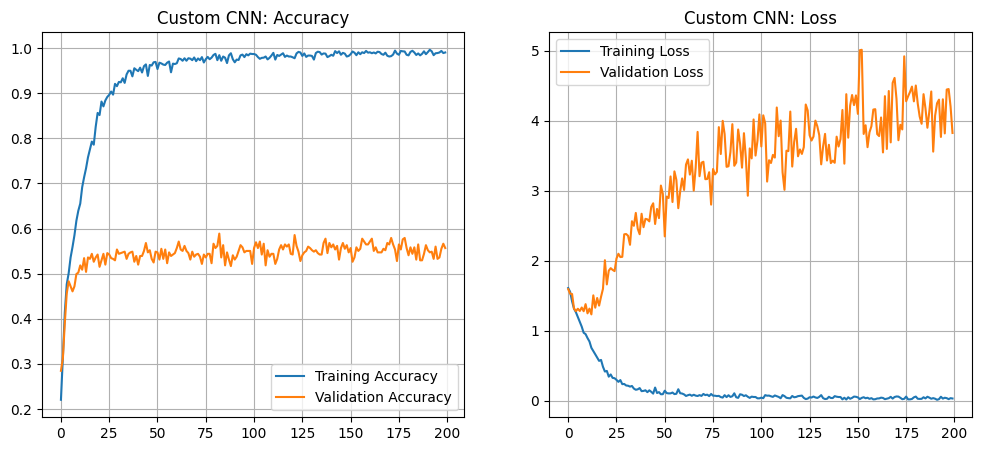

In [153]:
if history1:
    acc1 = history1.history['accuracy']
    val_acc1 = history1.history['val_accuracy']
    loss1 = history1.history['loss']
    val_loss1 = history1.history['val_loss']
    epochs_range1 = range(len(acc1))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range1, acc1, label='Training Accuracy')
    plt.plot(epochs_range1, val_acc1, label='Validation Accuracy')
    plt.title('Custom CNN: Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range1, loss1, label='Training Loss')
    plt.plot(epochs_range1, val_loss1, label='Validation Loss')
    plt.title('Custom CNN: Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

## **6.2. Insights from Model 3:**
**Looking at the chart above and the training of my Third model, I can tell that it is clearly overfitted with a final Training Accuracy of 99.53% and Validation accuracy of 55.68%.**

**As for the training and validation loss for the 3rd model, the training loss has dropped to less than 10% from the 60th epoch mark onwards, whereas the validation loss for this model is constantly increasing and it spike at times to over 4 and close to 5. This means that my model is detecting a lot of noise which is why there are high peaks and lows for my validation accuracy and loss.**

**As the addition of another 2D convolution layer immediately after one 2D Conv layer for this Model is slightly inconclusive on whether the additional layer of 2D Conv layer is useful to the improving the validation accuracy, reducing of the validation loss, and overfitting chances, I have decided to try and add a dropout layer to reduce the noise.**

## **7.1. Testing of 4th Model:** ##
**I decided to Try and add a 20% dropout layer after every Convolution 2D layer to make the model drop all the memorised noise that is potentially remembered by the model, this is to try and avoid the model from overfitting**

In [154]:
#Creating the model:
model2 = tf.keras.models.Sequential()
model2.add(tf.keras.layers.Input(shape=(224, 224, 3)))
model2.add(layers.Conv2D(16, (3, 3), padding='valid', activation='relu'))
model2.add(tf.keras.layers.Dropout(0.2))
model2.add(layers.Conv2D(16, (3, 3), padding='valid', activation='relu'))
model2.add(tf.keras.layers.Dropout(0.2))
model2.add(layers.MaxPooling2D((2, 2)))
model2.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model2.add(tf.keras.layers.Dropout(0.2))
model2.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model2.add(tf.keras.layers.Dropout(0.2))
model2.add(layers.MaxPooling2D((2, 2)))
model2.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model2.add(tf.keras.layers.Dropout(0.2))
model2.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model2.add(layers.MaxPooling2D((2, 2)))
model2.add(tf.keras.layers.Dropout(0.2))
model2.add(tf.keras.layers.Flatten())
model2.add(tf.keras.layers.Dense(128, activation='relu'))
model2.add(tf.keras.layers.Dense(5, activation="softmax"))
print(model2.summary())

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)                   │ (None, 222, 222, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_34 (Dropout)                 │ (None, 222, 222, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_28 (Conv2D)                   │ (None, 220, 220, 16)        │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_35 (Dropout)                 │ (None, 220, 220, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_24 (MaxPooling2D)      │ (None, 110, 110, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_29 (Conv2D)                   │ (None, 108, 108, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_36 (Dropout)                 │ (None, 108, 108, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_30 (Conv2D)                   │ (None, 106, 106, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_37 (Dropout)                 │ (None, 106, 106, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_25 (MaxPooling2D)      │ (None, 53, 53, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_31 (Conv2D)                   │ (None, 51, 51, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_38 (Dropout)                 │ (None, 51, 51, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_32 (Conv2D)                   │ (None, 49, 49, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_26 (MaxPooling2D)      │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_39 (Dropout)                 │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 18432)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 128)                 │       2,359,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,395,221 (9.14 MB)

 Trainable params: 2,395,221 (9.14 MB)

 Non-trainable params: 0 (0.00 B)

None


In [155]:
model2.compile(loss = "categorical_crossentropy", optimizer = "adam", metrics=["accuracy"])

In [156]:
history2 = model2.fit(train_generator, validation_data=validation_generator, epochs=200, verbose=1)

Epoch 1/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 16s 207ms/step - accuracy: 0.2018 - loss: 1.6803 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 2/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 206ms/step - accuracy: 0.2099 - loss: 1.6090 - val_accuracy: 0.1984 - val_loss: 1.6096
Epoch 3/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 204ms/step - accuracy: 0.2662 - loss: 1.5901 - val_accuracy: 0.2144 - val_loss: 1.6059
Epoch 4/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 204ms/step - accuracy: 0.3076 - loss: 1.5459 - val_accuracy: 0.2848 - val_loss: 1.5681
Epoch 5/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 204ms/step - accuracy: 0.3635 - loss: 1.4398 - val_accuracy: 0.3392 - val_loss: 1.4873
Epoch 6/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 206ms/step - accuracy: 0.3818 - loss: 1.4152 - val_accuracy: 0.3568 - val_loss: 1.4497
Epoch 7/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 205ms/step - accuracy: 0.4317 - loss: 1.3430 - val_accuracy: 0.4176 - val_loss: 1.4023
Epoch 8/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 205ms/step - accuracy: 0.4680 - loss: 1.2854 - 

In [157]:
model2.save("./models/musical_instruments_model2.keras")
print("Model2 saved to disk")

Model2 saved to disk


In [158]:
# Evaluate the model
model2 = tf.keras.models.load_model("./models/musical_instruments_model1.keras")
scores2_val = model2.evaluate(validation_generator, verbose=0)
print("Validation Accuracy: %.2f%%" % (scores2_val[1]*100))

scores2_train = model2.evaluate(train_generator, verbose=0)
print("Train Accuracy: %.2f%%" % (scores2_train[1]*100))

Validation Accuracy: 55.68%
Train Accuracy: 99.36%


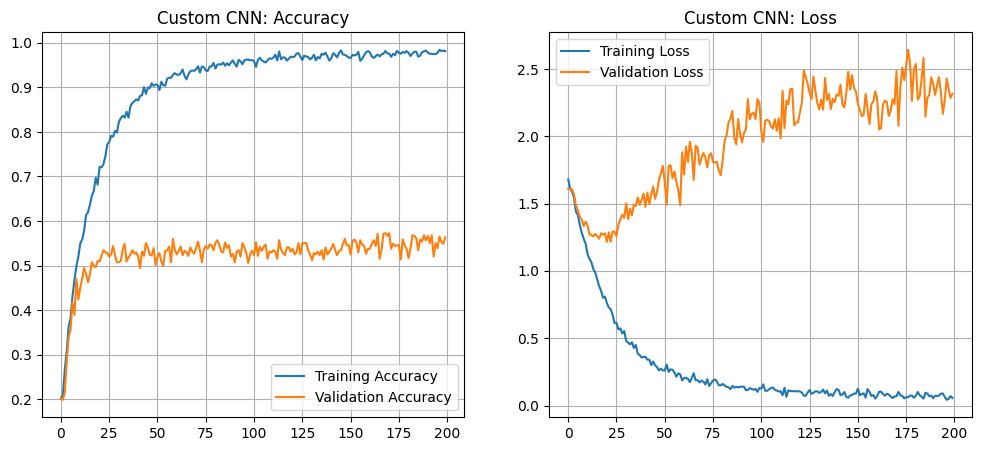

In [159]:
if history2:
    acc2 = history2.history['accuracy']
    val_acc2 = history2.history['val_accuracy']
    loss2 = history2.history['loss']
    val_loss2 = history2.history['val_loss']
    epochs_range2 = range(len(acc2))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range2, acc2, label='Training Accuracy')
    plt.plot(epochs_range2, val_acc2, label='Validation Accuracy')
    plt.title('Custom CNN: Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range2, loss2, label='Training Loss')
    plt.plot(epochs_range2, val_loss2, label='Validation Loss')
    plt.title('Custom CNN: Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

## **7.2. Insights from Model 4:**
**Although my 4th model is still overfitted with a final Training Accuracy of 99.36% and Validation accuracy of 55.68%, it has greatly improved with the dropout layer after every 2D Conv layer. At the 16th epochs, it has already hit the 90% mark for the training accuracy. As for the validation accuracy, it only reached a peak of 70.1% accuracy at the 149th epoch.**

**Although my validation accuracy is around the same range of my previous model's validation accuracy, the validation loss for this model has reduced to around 2.3 which is around half the validation loss of the previous model which is a good improvement, meaning that the use of a dropout layer is helpful to achieving my best trained model.**

**As my modely is clearly overfitted, I decided to continue training more models to find a more reasonable model with at least 70% accuracy and that of around high 80% accuracy to low 90% for both my Training and Validation Accuracy to ensure that my model is not overfitted.**

## **8.1. Testing of 5th Model:** ##
**I went on to further increase the dropout rate to 50% as it was still over fitted and to reduce the validation loss.**

In [160]:
#Creating the model:
model3 = tf.keras.models.Sequential()
model3.add(tf.keras.layers.Input(shape=(224, 224, 3)))
model3.add(layers.Conv2D(16, (3, 3), padding='valid', activation='relu'))
model3.add(tf.keras.layers.Dropout(0.5))
model3.add(layers.Conv2D(16, (3, 3), padding='valid', activation='relu'))
model3.add(tf.keras.layers.Dropout(0.5))
model3.add(layers.MaxPooling2D((2, 2)))
model3.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model3.add(tf.keras.layers.Dropout(0.5))
model3.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model3.add(tf.keras.layers.Dropout(0.5))
model3.add(layers.MaxPooling2D((2, 2)))
model3.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model3.add(tf.keras.layers.Dropout(0.5))
model3.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model3.add(layers.MaxPooling2D((2, 2)))
model3.add(tf.keras.layers.Dropout(0.5))
model3.add(tf.keras.layers.Flatten())
model3.add(tf.keras.layers.Dense(128, activation='relu'))
model3.add(tf.keras.layers.Dense(5, activation="softmax"))
print(model3.summary())

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)                   │ (None, 222, 222, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_40 (Dropout)                 │ (None, 222, 222, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_34 (Conv2D)                   │ (None, 220, 220, 16)        │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_41 (Dropout)                 │ (None, 220, 220, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_27 (MaxPooling2D)      │ (None, 110, 110, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_35 (Conv2D)                   │ (None, 108, 108, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_42 (Dropout)                 │ (None, 108, 108, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_36 (Conv2D)                   │ (None, 106, 106, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_43 (Dropout)                 │ (None, 106, 106, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_28 (MaxPooling2D)      │ (None, 53, 53, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_37 (Conv2D)                   │ (None, 51, 51, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_44 (Dropout)                 │ (None, 51, 51, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_38 (Conv2D)                   │ (None, 49, 49, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_29 (MaxPooling2D)      │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_45 (Dropout)                 │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_7 (Flatten)                  │ (None, 18432)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ (None, 128)                 │       2,359,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,395,221 (9.14 MB)

 Trainable params: 2,395,221 (9.14 MB)

 Non-trainable params: 0 (0.00 B)

None


In [161]:
model3.compile(loss = "categorical_crossentropy", optimizer = "adam", metrics=["accuracy"])

In [162]:
history3 = model3.fit(train_generator, validation_data=validation_generator, epochs=200, verbose=1)

Epoch 1/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 16s 206ms/step - accuracy: 0.2257 - loss: 1.7286 - val_accuracy: 0.2000 - val_loss: 1.6096
Epoch 2/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 204ms/step - accuracy: 0.2278 - loss: 1.6073 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 3/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 204ms/step - accuracy: 0.2611 - loss: 1.5826 - val_accuracy: 0.2640 - val_loss: 1.6071
Epoch 4/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 204ms/step - accuracy: 0.2931 - loss: 1.5568 - val_accuracy: 0.2000 - val_loss: 1.6109
Epoch 5/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 202ms/step - accuracy: 0.3161 - loss: 1.5499 - val_accuracy: 0.2000 - val_loss: 1.6135
Epoch 6/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 204ms/step - accuracy: 0.3387 - loss: 1.5066 - val_accuracy: 0.2000 - val_loss: 1.6116
Epoch 7/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 206ms/step - accuracy: 0.3537 - loss: 1.4712 - val_accuracy: 0.2048 - val_loss: 1.6140
Epoch 8/200
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 203ms/step - accuracy: 0.3498 - loss: 1.4626 - 

In [163]:
model3.save("./models/musical_instruments_model3.keras")
print("Model 3 saved to disk")

Model 3 saved to disk


In [164]:
# Evaluate the model
model3 = tf.keras.models.load_model("./models/musical_instruments_model1.keras")
scores3_val = model3.evaluate(validation_generator, verbose=0)
print("Validation Accuracy: %.2f%%" % (scores3_val[1]*100))

scores3_train = model3.evaluate(train_generator, verbose=0)
print("Train Accuracy: %.2f%%" % (scores3_train[1]*100))

Validation Accuracy: 55.68%
Train Accuracy: 99.57%


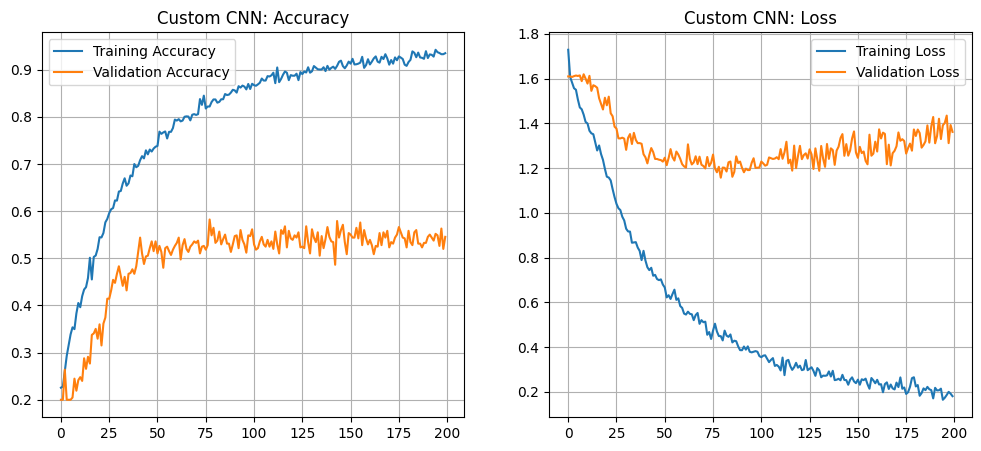

In [165]:
if history3:
    acc3 = history3.history['accuracy']
    val_acc3 = history3.history['val_accuracy']
    loss3 = history3.history['loss']
    val_loss3 = history3.history['val_loss']
    epochs_range3 = range(len(acc3))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range3, acc3, label='Training Accuracy')
    plt.plot(epochs_range3, val_acc3, label='Validation Accuracy')
    plt.title('Custom CNN: Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range3, loss3, label='Training Loss')
    plt.plot(epochs_range3, val_loss3, label='Validation Loss')
    plt.title('Custom CNN: Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

## **8.2. Insights from Model 5:**
**Although my 5th model is still overfitted with a final Training Accuracy of 99.57% and Validation accuracy of 55.68%, it is better with the dropout layer after every 2D Conv layer. At the 16th epochs, it has already hit the 90% mark for the training accuracy. As for the validation accuracy, it only reached a peak of 70.1% accuracy at the 149th epoch.**

**This is when I found out that the dropout layer doesn't affect the validation accuracy at all as the validation accuracy stayed the same for the past 3 Models (Models 3,4 and 5).**

**Although my validation accuracy is around the same range of my previous model's validation accuracy, the validation loss for this model has reduced to around 2.3 which is around half the validation loss of the previous model which is a good improvement, meaning that the use of a dropout layer is helpful to achieving my best trained model.**

## **9.1. Testing of 6th Model:** ##
**I decided to drop additional layers of padding and the dropout layers that comes with it as I was wondering if the model was detecting some noise from the image by making the edge depth one layer more**

In [166]:
#Creating the model:
model4 = tf.keras.models.Sequential()
model4.add(tf.keras.layers.Input(shape=(224, 224, 3)))
model4.add(layers.Conv2D(16, (3, 3), padding='valid', activation='relu'))
model4.add(tf.keras.layers.Dropout(0.5))
model4.add(layers.MaxPooling2D((2, 2)))
model4.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model4.add(tf.keras.layers.Dropout(0.5))
model4.add(layers.MaxPooling2D((2, 2)))
model4.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model4.add(layers.MaxPooling2D((2, 2)))
model4.add(tf.keras.layers.Dropout(0.5))
model4.add(tf.keras.layers.Flatten())
model4.add(tf.keras.layers.Dense(128, activation='relu'))
model4.add(tf.keras.layers.Dense(5, activation="softmax"))
print(model4.summary())

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_39 (Conv2D)                   │ (None, 222, 222, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_46 (Dropout)                 │ (None, 222, 222, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_30 (MaxPooling2D)      │ (None, 111, 111, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_40 (Conv2D)                   │ (None, 109, 109, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_47 (Dropout)                 │ (None, 109, 109, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_31 (MaxPooling2D)      │ (None, 54, 54, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_41 (Conv2D)                   │ (None, 52, 52, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_32 (MaxPooling2D)      │ (None, 26, 26, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_48 (Dropout)                 │ (None, 26, 26, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_8 (Flatten)                  │ (None, 21632)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 128)                 │       2,769,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,784,005 (10.62 MB)

 Trainable params: 2,784,005 (10.62 MB)

 Non-trainable params: 0 (0.00 B)

None


In [167]:
model4.compile(loss = "categorical_crossentropy", optimizer = "adam", metrics=["accuracy"])

In [168]:
history4 = model4.fit(train_generator, validation_data=validation_generator, epochs=100, verbose=1)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 13s 165ms/step - accuracy: 0.2180 - loss: 1.7705 - val_accuracy: 0.2512 - val_loss: 1.6016
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 164ms/step - accuracy: 0.3400 - loss: 1.5394 - val_accuracy: 0.3136 - val_loss: 1.5502
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 163ms/step - accuracy: 0.4189 - loss: 1.4168 - val_accuracy: 0.3360 - val_loss: 1.4900
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 164ms/step - accuracy: 0.4637 - loss: 1.3207 - val_accuracy: 0.4016 - val_loss: 1.4277
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 164ms/step - accuracy: 0.4872 - loss: 1.2545 - val_accuracy: 0.4096 - val_loss: 1.4013
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 164ms/step - accuracy: 0.5230 - loss: 1.2085 - val_accuracy: 0.4672 - val_loss: 1.3494
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 164ms/step - accuracy: 0.5418 - loss: 1.1637 - val_accuracy: 0.4480 - val_loss: 1.3612
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 167ms/step - accuracy: 0.5631 - loss: 1.1109 - 

In [169]:
model4.save("./models/musical_instruments_model4.keras")
print("Model 4 saved to disk")

Model 4 saved to disk


In [170]:
# Evaluate the model
model4 = tf.keras.models.load_model("./models/musical_instruments_model1.keras")
scores4_val = model4.evaluate(validation_generator, verbose=0)
print("Validation Accuracy: %.2f%%" % (scores4_val[1]*100))

scores4_train = model4.evaluate(train_generator, verbose=0)
print("Train Accuracy: %.2f%%" % (scores4_train[1]*100))

Validation Accuracy: 55.68%
Train Accuracy: 99.66%


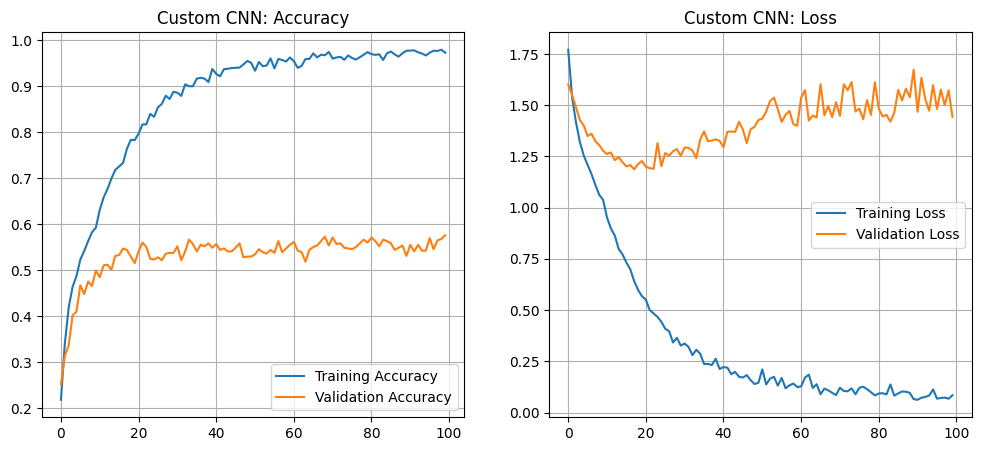

In [171]:
if history4:
    acc4 = history4.history['accuracy']
    val_acc4 = history4.history['val_accuracy']
    loss4 = history4.history['loss']
    val_loss4 = history4.history['val_loss']
    epochs_range4 = range(len(acc4))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range4, acc4, label='Training Accuracy')
    plt.plot(epochs_range4, val_acc4, label='Validation Accuracy')
    plt.title('Custom CNN: Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range4, loss4, label='Training Loss')
    plt.plot(epochs_range4, val_loss4, label='Validation Loss')
    plt.title('Custom CNN: Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

## **9.2. Insights from Model 6:**
**Model 6's final Training Accuracy of 99.66% and Validation accuracy of 55.68%. The average validation accuracy is only 55%.**

**As the validation loss is lower than that of model 5, I decided to keep the 2nd back to back Conv2D layer with the dropout layer that comes after them**

## **10.1. Testing of 7th Model:** ##
**Back to back MaxPooling2D layers**

In [172]:
#Creating the model:
model5 = tf.keras.models.Sequential()
model5.add(tf.keras.layers.Input(shape=(224, 224, 3)))
model5.add(layers.Conv2D(16, (3, 3), padding='valid', activation='relu'))
model5.add(tf.keras.layers.Dropout(0.5))
model5.add(layers.Conv2D(16, (3, 3), padding='valid', activation='relu'))
model5.add(tf.keras.layers.Dropout(0.5))
model5.add(layers.MaxPooling2D((2, 2)))
model5.add(layers.MaxPooling2D((2, 2)))
model5.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model5.add(tf.keras.layers.Dropout(0.5))
model5.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model5.add(tf.keras.layers.Dropout(0.5))
model5.add(layers.MaxPooling2D((2, 2)))
model5.add(layers.MaxPooling2D((2, 2)))
model5.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model5.add(tf.keras.layers.Dropout(0.5))
model5.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model5.add(layers.MaxPooling2D((2, 2)))
model5.add(layers.MaxPooling2D((2, 2)))
model5.add(tf.keras.layers.Dropout(0.5))
model5.add(tf.keras.layers.Flatten())
model5.add(tf.keras.layers.Dense(128, activation='relu'))
model5.add(tf.keras.layers.Dense(5, activation="softmax"))
print(model5.summary())

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)                   │ (None, 222, 222, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_49 (Dropout)                 │ (None, 222, 222, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_43 (Conv2D)                   │ (None, 220, 220, 16)        │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_50 (Dropout)                 │ (None, 220, 220, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_33 (MaxPooling2D)      │ (None, 110, 110, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_34 (MaxPooling2D)      │ (None, 55, 55, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_44 (Conv2D)                   │ (None, 53, 53, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_51 (Dropout)                 │ (None, 53, 53, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_45 (Conv2D)                   │ (None, 51, 51, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_52 (Dropout)                 │ (None, 51, 51, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_35 (MaxPooling2D)      │ (None, 25, 25, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_36 (MaxPooling2D)      │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_46 (Conv2D)                   │ (None, 10, 10, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_53 (Dropout)                 │ (None, 10, 10, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_47 (Conv2D)                   │ (None, 8, 8, 32)            │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_37 (MaxPooling2D)      │ (None, 4, 4, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_38 (MaxPooling2D)      │ (None, 2, 2, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_54 (Dropout)                 │ (None, 2, 2, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_9 (Flatten)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_51 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_52 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 52,309 (204.33 KB)

 Trainable params: 52,309 (204.33 KB)

 Non-trainable params: 0 (0.00 B)

None


In [173]:
model5.compile(loss = "categorical_crossentropy", optimizer = "adam", metrics=["accuracy"])

In [174]:
history5 = model5.fit(train_generator, validation_data=validation_generator, epochs=50, verbose=1)

Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 186ms/step - accuracy: 0.2108 - loss: 1.6510 - val_accuracy: 0.2032 - val_loss: 1.6095
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 183ms/step - accuracy: 0.2338 - loss: 1.5967 - val_accuracy: 0.2128 - val_loss: 1.6091
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 183ms/step - accuracy: 0.2765 - loss: 1.5830 - val_accuracy: 0.2000 - val_loss: 1.6137
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 183ms/step - accuracy: 0.2978 - loss: 1.5597 - val_accuracy: 0.2000 - val_loss: 1.6180
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 182ms/step - accuracy: 0.3306 - loss: 1.5459 - val_accuracy: 0.2096 - val_loss: 1.6217
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 183ms/step - accuracy: 0.3520 - loss: 1.4934 - val_accuracy: 0.2144 - val_loss: 1.6308
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 183ms/step - accuracy: 0.3626 - loss: 1.4652 - val_accuracy: 0.2176 - val_loss: 1.6313
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 187ms/step - accuracy: 0.3887 - loss: 1.4162 - val_accu

In [215]:
# Evaluate the model
model5 = tf.keras.models.load_model("./models/musical_instruments_model5.keras")
scores5_val = model5.evaluate(validation_generator, verbose=0)
print("Validation Accuracy: %.2f%%" % (scores5_val[1]*100))

scores5_train = model5.evaluate(train_generator, verbose=0)
print("Train Accuracy: %.2f%%" % (scores5_train[1]*100))

Validation Accuracy: 55.68%
Train Accuracy: 99.57%


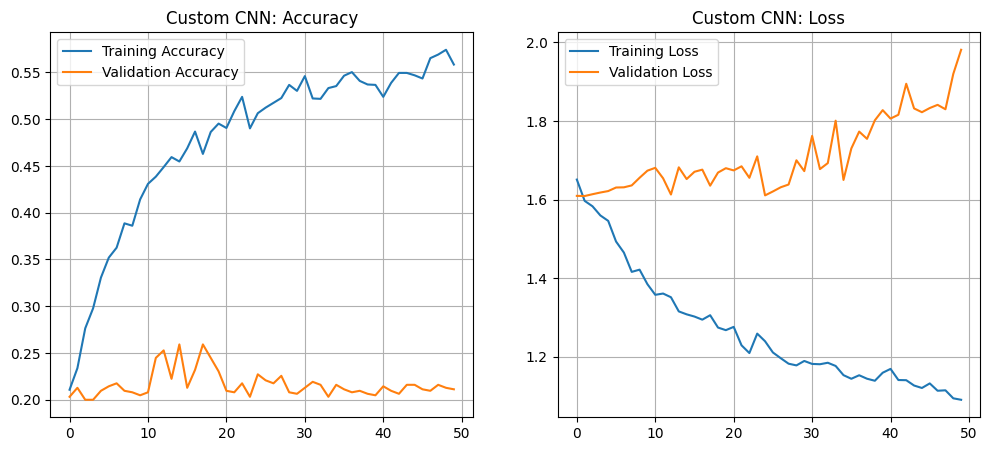

In [176]:
if history5:
    acc5 = history5.history['accuracy']
    val_acc5 = history5.history['val_accuracy']
    loss5 = history5.history['loss']
    val_loss5 = history5.history['val_loss']
    epochs_range5 = range(len(acc5))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range5, acc5, label='Training Accuracy')
    plt.plot(epochs_range5, val_acc5, label='Validation Accuracy')
    plt.title('Custom CNN: Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range5, loss5, label='Training Loss')
    plt.plot(epochs_range5, val_loss5, label='Validation Loss')
    plt.title('Custom CNN: Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [177]:
model5.save("./models/musical_instruments_model5.keras")
print("Model 5 saved to disk")

Model 5 saved to disk


## **10.2. Insights from Model 7:** ##
**Just one glance at the chart above and the training of my 7th model, I can tell that it is clearly under fitted with a final Training Accuracy of 55.84% and Validation accuracy of 21.12%.**

**I will be most likely use back to back MaxPooling2D layers in my future models to better balance out my future models as most of my models are currently overfitted to create a well-balanced model..**

## **11.1. Testing of 8th Model:** ##
**I decided to remove the Dropout layer between each 2 Conv2D layers as the previous model was underfitted. I did this as the model is currently underfitted and not overfitted.**

In [178]:
#Creating the model:
model6 = tf.keras.models.Sequential()
model6.add(tf.keras.layers.Input(shape=(224, 224, 3)))
model6.add(layers.Conv2D(16, (3, 3), padding='valid', activation='relu'))
model6.add(layers.Conv2D(16, (3, 3), padding='valid', activation='relu'))
model6.add(tf.keras.layers.Dropout(0.5))
model6.add(layers.MaxPooling2D((2, 2)))
model6.add(layers.MaxPooling2D((2, 2)))
model6.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model6.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model6.add(tf.keras.layers.Dropout(0.5))
model6.add(layers.MaxPooling2D((2, 2)))
model6.add(layers.MaxPooling2D((2, 2)))
model6.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model6.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model6.add(layers.MaxPooling2D((2, 2)))
model6.add(layers.MaxPooling2D((2, 2)))
model6.add(tf.keras.layers.Dropout(0.5))
model6.add(tf.keras.layers.Flatten())
model6.add(tf.keras.layers.Dense(128, activation='relu'))
model6.add(tf.keras.layers.Dense(5, activation="softmax"))
print(model6.summary())

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)                   │ (None, 222, 222, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_49 (Conv2D)                   │ (None, 220, 220, 16)        │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_55 (Dropout)                 │ (None, 220, 220, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_39 (MaxPooling2D)      │ (None, 110, 110, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_40 (MaxPooling2D)      │ (None, 55, 55, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_50 (Conv2D)                   │ (None, 53, 53, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_51 (Conv2D)                   │ (None, 51, 51, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_56 (Dropout)                 │ (None, 51, 51, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_41 (MaxPooling2D)      │ (None, 25, 25, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_42 (MaxPooling2D)      │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_52 (Conv2D)                   │ (None, 10, 10, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_53 (Conv2D)                   │ (None, 8, 8, 32)            │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_43 (MaxPooling2D)      │ (None, 4, 4, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_44 (MaxPooling2D)      │ (None, 2, 2, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_57 (Dropout)                 │ (None, 2, 2, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_10 (Flatten)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_53 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_54 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,309 (204.33 KB)

 Trainable params: 52,309 (204.33 KB)

 Non-trainable params: 0 (0.00 B)

None


In [179]:
model6.compile(loss = "categorical_crossentropy", optimizer = "adam", metrics=["accuracy"])
history6 = model6.fit(train_generator, validation_data=validation_generator, epochs=100, verbose=1)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 13s 164ms/step - accuracy: 0.2009 - loss: 1.6108 - val_accuracy: 0.2384 - val_loss: 1.6060
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms/step - accuracy: 0.2713 - loss: 1.5833 - val_accuracy: 0.3152 - val_loss: 1.5641
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 162ms/step - accuracy: 0.3686 - loss: 1.4529 - val_accuracy: 0.3552 - val_loss: 1.4661
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 162ms/step - accuracy: 0.4249 - loss: 1.3925 - val_accuracy: 0.3184 - val_loss: 1.5027
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms/step - accuracy: 0.4595 - loss: 1.3343 - val_accuracy: 0.4224 - val_loss: 1.4131
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 162ms/step - accuracy: 0.4770 - loss: 1.2920 - val_accuracy: 0.4608 - val_loss: 1.4065
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 164ms/step - accuracy: 0.4949 - loss: 1.2620 - val_accuracy: 0.4608 - val_loss: 1.3808
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 164ms/step - accuracy: 0.5183 - loss: 1.2152 - 

In [180]:
model6.save("./models/musical_instruments_model6.keras")
print("Model 6 saved to disk")

Model 6 saved to disk


In [183]:
## Load the previously saved model
model6 = tf.keras.models.load_model("./models/musical_instruments_model6.keras")

# Evaluate the model
scores6_val = model6.evaluate(validation_generator, verbose=0)
print("Validation Accuracy: %.2f%%" % (scores6_val[1]*100))

score6_train = model6.evaluate(train_generator, verbose=0)
print("Train Accuracy: %.2f%%" % (scores6_train[1]*100))

Validation Accuracy: 63.36%
Train Accuracy: 76.79%


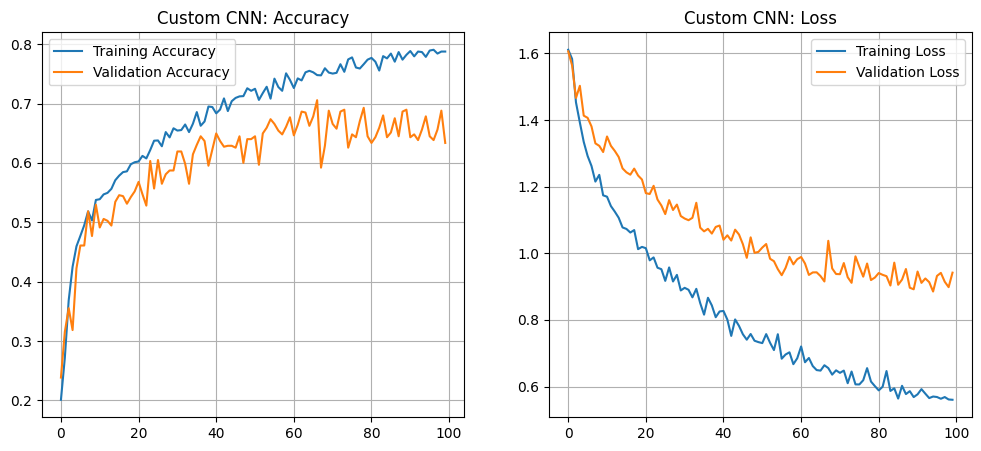

In [181]:
if history6:
    acc6 = history6.history['accuracy']
    val_acc6 = history6.history['val_accuracy']
    loss6 = history6.history['loss']
    val_loss6 = history6.history['val_loss']
    epochs_range6 = range(len(acc6))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range6, acc6, label='Training Accuracy')
    plt.plot(epochs_range6, val_acc6, label='Validation Accuracy')
    plt.title('Custom CNN: Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range6, loss6, label='Training Loss')
    plt.plot(epochs_range6, val_loss6, label='Validation Loss')
    plt.title('Custom CNN: Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

## **11.2. Insights from Model 8:**
**This model is now well-balanced, with its final Training Accuracy being 76.79% and Validation accuracy of 63.36%.**

**Additionally, the CNN model's loss for both training and validation are both decreasing as the number of epochs increases which is another reason why it is a well-balanced model.**

**My Future steps to take now are to use this model as a base and improve it and use it for transfer learning.**

## **12.1. Attempt to improve Model 8 by increasing the neurons of Conv2D layers in Model 8:** ##

In [225]:
#Creating the model:
model7 = tf.keras.models.Sequential()
model7.add(tf.keras.layers.Input(shape=(224, 224, 3)))
model7.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model7.add(layers.Conv2D(32, (3, 3), padding='valid', activation='relu'))
model7.add(tf.keras.layers.Dropout(0.5))
model7.add(layers.MaxPooling2D((2, 2)))
model7.add(layers.MaxPooling2D((2, 2)))
model7.add(layers.Conv2D(64, (3, 3), padding='valid', activation='relu'))
model7.add(layers.Conv2D(64, (3, 3), padding='valid', activation='relu'))
model7.add(tf.keras.layers.Dropout(0.5))
model7.add(layers.MaxPooling2D((2, 2)))
model7.add(layers.MaxPooling2D((2, 2)))
model7.add(layers.Conv2D(128, (3, 3), padding='valid', activation='relu'))
model7.add(layers.Conv2D(128, (3, 3), padding='valid', activation='relu'))
model7.add(layers.MaxPooling2D((2, 2)))
model7.add(layers.MaxPooling2D((2, 2)))
model7.add(tf.keras.layers.Dropout(0.5))
model7.add(tf.keras.layers.Flatten())
model7.add(tf.keras.layers.Dense(128, activation='relu'))
model7.add(tf.keras.layers.Dense(5, activation="softmax"))
print(model7.summary())

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_85 (Conv2D)                   │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_86 (Conv2D)                   │ (None, 220, 220, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_81 (Dropout)                 │ (None, 220, 220, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_69 (MaxPooling2D)      │ (None, 110, 110, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_70 (MaxPooling2D)      │ (None, 55, 55, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_87 (Conv2D)                   │ (None, 53, 53, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_88 (Conv2D)                   │ (None, 51, 51, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_82 (Dropout)                 │ (None, 51, 51, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_71 (MaxPooling2D)      │ (None, 25, 25, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_72 (MaxPooling2D)      │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_89 (Conv2D)                   │ (None, 10, 10, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_90 (Conv2D)                   │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_73 (MaxPooling2D)      │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_74 (MaxPooling2D)      │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_83 (Dropout)                 │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_15 (Flatten)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_77 (Dense)                     │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_78 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 353,317 (1.35 MB)

 Trainable params: 353,317 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

None


In [227]:
model7.compile(loss = "categorical_crossentropy", optimizer = "adam", metrics=["accuracy"])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('./models/checkpoints/model7_best.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

history7 = model7.fit(train_generator, validation_data=validation_generator, epochs=100, callbacks = callbacks, verbose=1)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.5247 - loss: 1.1680
Epoch 1: val_accuracy improved from None to 0.51520, saving model to ./models/checkpoints/model7_best.keras

Epoch 1: finished saving model to ./models/checkpoints/model7_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 228ms/step - accuracy: 0.5401 - loss: 1.1380 - val_accuracy: 0.5152 - val_loss: 1.2628 - learning_rate: 0.0010
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.5804 - loss: 1.0761
Epoch 2: val_accuracy improved from 0.51520 to 0.53120, saving model to ./models/checkpoints/model7_best.keras

Epoch 2: finished saving model to ./models/checkpoints/model7_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 17s 226ms/step - accuracy: 0.5785 - loss: 1.0867 - val_accuracy: 0.5312 - val_loss: 1.2918 - learning_rate: 0.0010
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.5866 - loss: 1.0633
Epoch 3: val_accuracy improved from 0.53120 to 0.58080, saving model to ./models/checkpo

In [228]:
model7.save("./models/musical_instruments_model7.keras")
print("Model 7 is saved")

model7.save_weights('./models/musical_instruments_model7.weights.h5')
print("Weights-only file also saved (HDF5 format).")

Model 7 is saved
Weights-only file also saved (HDF5 format).


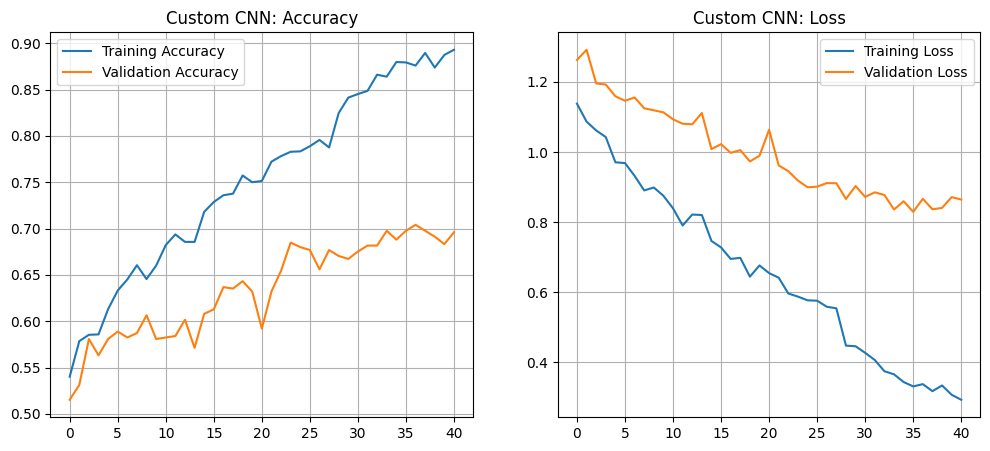

In [234]:
if history7:
    acc7 = history7.history['accuracy']
    val_acc7 = history7.history['val_accuracy']
    loss7 = history7.history['loss']
    val_loss7 = history7.history['val_loss']
    epochs_range7 = range(len(acc7))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range7, acc7, label='Training Accuracy')
    plt.plot(epochs_range7, val_acc7, label='Validation Accuracy')
    plt.title('Custom CNN: Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range7, loss7, label='Training Loss')
    plt.plot(epochs_range7, val_loss7, label='Validation Loss')
    plt.title('Custom CNN: Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

## **12.2. Neurons Increase Outcome:** ##
**With the increase in the number of kernels in the Conv2D layers, the model has overfitted even more, going from 76.79% training accuracy to 89.29% training accuracy. Whereas, the validation accuracy went from 63.36% to 69.60%. Although there is a slight increase in the validation accuracy, the increase in the training accuracy far supassed that of the validation accuracy increase. Additionally, the gap between the Training and Validation Accuracy is way too big; hence the neurons increase actually caused the model to be overfitted.**

## **12.3. Improvement of the current best CNN Trained Model:** ##

**Preparing of Advance Image Augmentatation:** 

In [194]:
train_datagen1 = ImageDataGenerator(
    rescale = 1./255,
    
    rotation_range=30,              
    width_shift_range=0.2,         
    height_shift_range=0.2,        
    shear_range=0.2,               
    zoom_range=[0.75, 1.35],        # zoom in + out
    brightness_range=[0.65, 1.35],  # very important for real-world variation
    horizontal_flip=True,
    channel_shift_range=20.0,
    fill_mode='nearest'             
)

train_generator1 = train_datagen1.flow_from_directory(Training_data, target_size=target_size, batch_size=batch_size, class_mode='categorical')

Found 2344 images belonging to 5 classes.


In [197]:
## Load the previous best saved model:
model_trained_best0 = tf.keras.models.load_model("./models/musical_instruments_model6.keras")

In [ ]:
model_trained_best0.compile(loss = "categorical_crossentropy", optimizer = "adam", metrics=["accuracy"])
history_trained_best0 = model_trained_best0.fit(train_generator1, validation_data=validation_generator, epochs=100, verbose=1)

In [230]:
model_trained_best0.save("./models/musical_instruments_model_trained_best0.keras")
print("Model Trained Best 0 is saved")

model_trained_best0.save_weights('./models/musical_instruments_model_trained_best0.weights.h5')
print("Weights-only file also saved (HDF5 format).")

Model Trained Best 0 is saved
Weights-only file also saved (HDF5 format).


In [242]:
# Evaluate the model
model_trained_best0 = tf.keras.models.load_model("./models/musical_instruments_model_trained_best0.keras")

scores_best0_val = model_trained_best0.evaluate(validation_generator, verbose=0)
print("Validation Accuracy: %.2f%%" % (scores_best0_val[1]*100))

scores_best0_train = model_trained_best0.evaluate(train_generator1, verbose=0)
print("Train Accuracy: %.2f%%" % (scores_best0_train[1]*100))

Validation Accuracy: 68.64%
Train Accuracy: 74.19%


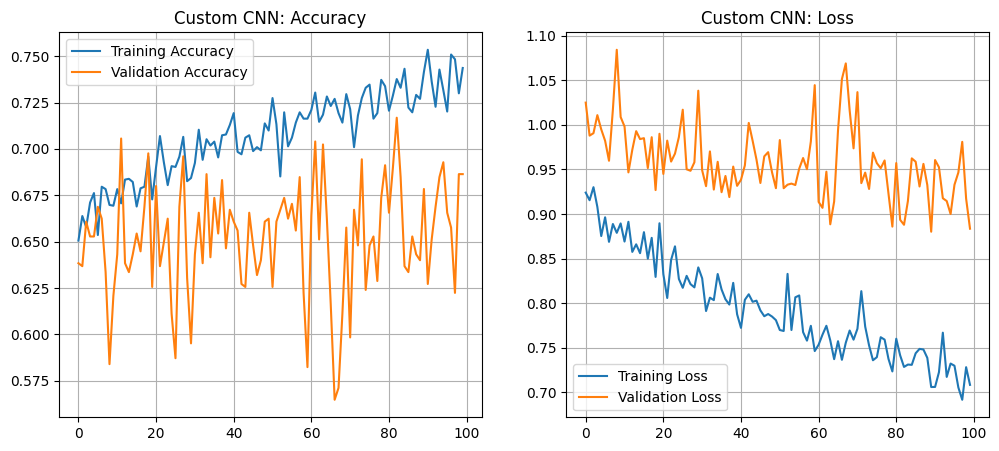

In [231]:
if history_trained_best0:
    acc_best0 = history_trained_best0.history['accuracy']
    val_acc_best0 = history_trained_best0.history['val_accuracy']
    loss_best0 = history_trained_best0.history['loss']
    val_loss_best0 = history_trained_best0.history['val_loss']
    epochs_range_best0 = range(len(acc_best0))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range_best0, acc_best0, label='Training Accuracy')
    plt.plot(epochs_range_best0, val_acc_best0, label='Validation Accuracy')
    plt.title('Custom CNN: Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range_best0, loss_best0, label='Training Loss')
    plt.plot(epochs_range_best0, val_loss_best0, label='Validation Loss')
    plt.title('Custom CNN: Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

## **12.4. Evaluation of the current best Model (Model 8) with advanced Image Augmentations:** ##
**From the 2 charts above, I can clearly see that with the more advanced image augmentations, the Training Accuracy (74.19%) and Validation accuracy (68.64%) is closer together compared to that when the basic image augmentation was used.**

**Additionally, the Loss for both the Training and Validation are now more in sync with each other. This means that the model is now slightly less overfitted with the more advanced Image Augmentation.**

## **12.5. Improving Model 8 by using Batched Normalization and modifying the dropout percentage:** ##

In [205]:
model_trained_best1 = tf.keras.models.Sequential()

model_trained_best1.add(tf.keras.Input(shape=(224,224,3)))

# Block 1
model_trained_best1.add(layers.Conv2D(32, 3, padding='same', activation='relu'))
model_trained_best1.add(layers.BatchNormalization())
model_trained_best1.add(layers.Conv2D(32, 3, padding='same', activation='relu'))
model_trained_best1.add(layers.BatchNormalization())
model_trained_best1.add(layers.MaxPooling2D())
model_trained_best1.add(layers.Dropout(0.25))

# Block 2
model_trained_best1.add(layers.Conv2D(64, 3, padding='same', activation='relu'))
model_trained_best1.add(layers.BatchNormalization())
model_trained_best1.add(layers.Conv2D(64, 3, padding='same', activation='relu'))
model_trained_best1.add(layers.BatchNormalization())
model_trained_best1.add(layers.MaxPooling2D())
model_trained_best1.add(layers.Dropout(0.35))

# Block 3
model_trained_best1.add(layers.Conv2D(128, 3, padding='same', activation='relu'))
model_trained_best1.add(layers.BatchNormalization())
model_trained_best1.add(layers.Conv2D(128, 3, padding='same', activation='relu'))
model_trained_best1.add(layers.BatchNormalization())
model_trained_best1.add(layers.MaxPooling2D())
model_trained_best1.add(layers.Dropout(0.4))

# Head
model_trained_best1.add(layers.GlobalAveragePooling2D())          # ← much better than Flatten

model_trained_best1.add(layers.Dense(512, activation='relu'))
model_trained_best1.add(layers.BatchNormalization())
model_trained_best1.add(layers.Dropout(0.45))

model_trained_best1.add(layers.Dense(5, activation='softmax'))
model_trained_best1.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_55 (Conv2D)                   │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_17               │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_56 (Conv2D)                   │ (None, 224, 224, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_18               │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_45 (MaxPooling2D)      │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_63 (Dropout)                 │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_57 (Conv2D)                   │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_19               │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_58 (Conv2D)                   │ (None, 112, 112, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_20               │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_46 (MaxPooling2D)      │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_64 (Dropout)                 │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_59 (Conv2D)                   │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_21               │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_60 (Conv2D)                   │ (None, 56, 56, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_22               │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_47 (MaxPooling2D)      │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_65 (Dropout)                 │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 359,461 (1.37 MB)

 Trainable params: 357,541 (1.36 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [206]:
model_trained_best1.compile(loss = "categorical_crossentropy", optimizer = "adam", metrics=["accuracy"])
history_best1 = model_trained_best1.fit(train_generator1, validation_data=validation_generator, epochs=100, verbose=1)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 55s 711ms/step - accuracy: 0.2509 - loss: 2.1505 - val_accuracy: 0.2000 - val_loss: 1.7538
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 52s 707ms/step - accuracy: 0.2914 - loss: 1.9467 - val_accuracy: 0.2000 - val_loss: 1.7127
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 52s 701ms/step - accuracy: 0.3016 - loss: 1.8658 - val_accuracy: 0.2064 - val_loss: 1.8322
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 52s 698ms/step - accuracy: 0.2948 - loss: 1.8289 - val_accuracy: 0.2352 - val_loss: 1.7063
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 52s 702ms/step - accuracy: 0.3319 - loss: 1.7180 - val_accuracy: 0.2656 - val_loss: 1.6433
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 52s 700ms/step - accuracy: 0.3404 - loss: 1.6639 - val_accuracy: 0.2912 - val_loss: 1.7717
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 51s 689ms/step - accuracy: 0.3660 - loss: 1.6035 - val_accuracy: 0.3920 - val_loss: 1.4780
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 51s 691ms/step - accuracy: 0.3933 - loss: 1.5214 - 

In [244]:
model_trained_best1.save("./models/musical_instruments_model_trained_best1.keras")
print("Model: model_trained_best1 is saved")

Model: model_trained_best1 is saved


## **12.6. Best Trained Model Evaluation:** ##
**The latest model with the use of Batch Normalization has improved my model to hit the minimum target of this project of 70% with the Target Accuracy being 86.52% and Validation Accuracy of 72.16%.**

In [ ]:
if history_trained_best1:
    acc_best1 = history_trained_best1.history['accuracy']
    val_acc_best1 = history_trained_best1.history['val_accuracy']
    loss_best1 = history_trained_best1.history['loss']
    val_loss_best1 = history_trained_best1.history['val_loss']
    epochs_range_best1 = range(len(acc_best1))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range_best1, acc_best1, label='Training Accuracy')
    plt.plot(epochs_range_best1, val_acc_best1, label='Validation Accuracy')
    plt.title('Custom CNN: Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range_best1, loss_best1, label='Training Loss')
    plt.plot(epochs_range_best1, val_loss_best1, label='Validation Loss')
    plt.title('Custom CNN: Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

Generating Confusion Matrix for Custom Baseline...


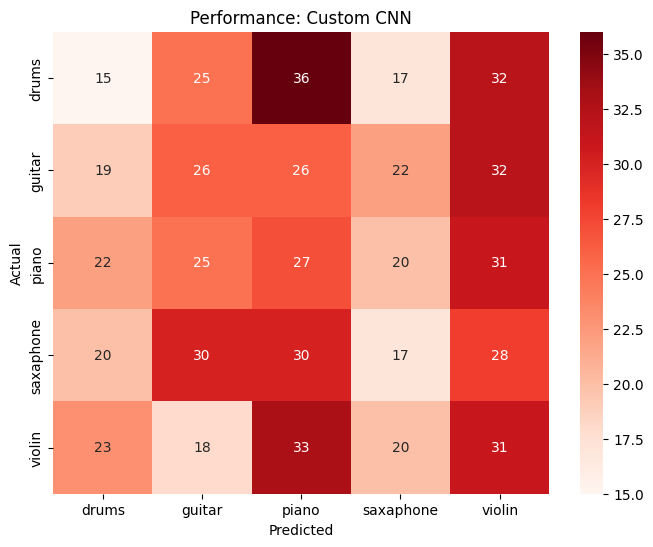

--- Custom Model Report ---
              precision    recall  f1-score   support

       drums       0.15      0.12      0.13       125
      guitar       0.21      0.21      0.21       125
       piano       0.18      0.22      0.19       125
   saxaphone       0.18      0.14      0.15       125
      violin       0.20      0.25      0.22       125

    accuracy                           0.19       625
   macro avg       0.18      0.19      0.18       625
weighted avg       0.18      0.19      0.18       625



In [237]:
# 2. Confusion Matrix
print("Generating Confusion Matrix for Custom Baseline...")
validation_generator.reset()
Y_pred = model_trained_best1.predict(validation_generator, verbose=0)
y_pred = np.argmax(Y_pred, axis=1)
y_true = validation_generator.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Performance: Custom CNN')
plt.show()

print("--- Custom Model Report ---")
print(classification_report(y_true, y_pred, target_names=class_labels))

**From the Confusion Matrix above, I can tell that although my best trained model's validation is 70%, it is actually not really/truly at least 70% accurate. This can be seen from the 0.19 for accuracy in the Classification Report.**

**From what I can infer, the best Trained Model that I have created is memorising details in the images and picking up on noises instead of learning infomation such as edges, shapes and features.**

**Hence, I will be moving on to transfer learning instead to have a better model for this project.**

# **Use of Pre-Trained CNN Models:**

## **13.1. Use of Pre-Trained MobileNetV3 Model:** ##

In [186]:
Pretrained_Model_Path = './models/musical_instruments_model_mobilenetv3.keras'

if os.path.exists(Pretrained_Model_Path):
    print(f"Found saved MobileNetV3 model. Loading model...")
    MV3_model = tf.keras.models.load_model(Pretrained_Model_Path)
    print("MobileNetV3 Model loaded in.")
    history_0 = None

    # Evaluate the model
    scores_MV3 = MV3_model.evaluate(validation_generator, verbose=0)
    print("Validation Accuracy: %.2f%%" % (scores_main_val[1]*100))

    scores_MV3 = MV3_model.evaluate(train_generator, verbose=0)
    print("Train Accuracy: %.2f%%" % (scores_MV3[1]*100))
else:
    print(" Training MobileNetV3 model:")
    
    # 1. Architecture
    MobileNetV3_model = MobileNetV3Small(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    MobileNetV3_model.trainable = False 
    
    x = MobileNetV3_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    predictions = layers.Dense(num_classes, activation='softmax')(x)
    
    MNV3_model = Model(inputs=MobileNetV3_model.input, outputs=predictions)
    
    # 2. Compile & Train
    MNV3_model.compile(loss = "categorical_crossentropy", optimizer = "adam", metrics=["accuracy"])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    history_0 = MNV3_model.fit(train_generator, validation_data=validation_generator, epochs=50, callbacks=[early_stop], verbose=1)
    
    # 3. Save
    MNV3_model.save(Pretrained_Model_Path)
    print(f"MobileNetV3 (Small) Model saved to '{Pretrained_Model_Path}'")

 Training MobileNetV3 model:
Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 162ms/step - accuracy: 0.2061 - loss: 1.6394 - val_accuracy: 0.2816 - val_loss: 1.6006
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 146ms/step - accuracy: 0.2261 - loss: 1.6082 - val_accuracy: 0.2176 - val_loss: 1.6010
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 148ms/step - accuracy: 0.2410 - loss: 1.6055 - val_accuracy: 0.2864 - val_loss: 1.5916
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 144ms/step - accuracy: 0.2329 - loss: 1.5975 - val_accuracy: 0.2496 - val_loss: 1.5977
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 144ms/step - accuracy: 0.2462 - loss: 1.5919 - val_accuracy: 0.2544 - val_loss: 1.5883
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 144ms/step - accuracy: 0.2530 - loss: 1.5847 - val_accuracy: 0.2768 - val_loss: 1.5749
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 143ms/step - accuracy: 0.2645 - loss: 1.5781 - val_accuracy: 0.2352 - val_loss: 1.5894
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 143ms/step - accuracy: 0.2

## **13.2. Evaluation of Pre-Trained MobileNetV3 Model:** ##
**Although this model (MobileNetV3) is not overfitted with the final accuracy of 34.30% for Training and 33.12% for validation, it is a very low accuracy, and hence I feel that I should not try to improve this model as it seems incompatible with my dataset for this project.**

## **14.1. Use of Pre-Trained EfficientNetV2 Model:** ##

In [209]:
EPOCHS_PHASE1 = 50
EPOCHS_PHASE2 = 100

MODEL_SAVE_PATH = './models/musical_instruments_efficientnetv2s.keras'
CHECKPOINT_PATH = './models/checkpoints/effnetv2s_best.keras'

print("Class indices:", train_generator.class_indices)

# ── Build Model ───────────────────────────────────────────────────────────────
def build_efficientnetv2s_model():
    base_model = EfficientNetV2S(
        include_top=False,
        weights='imagenet',
        input_shape=(*target_size, 3),
        pooling=None                 
    )
    
    # Freeze base at first
    base_model.trainable = False
    
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)
    
    predictions = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=predictions)
    return model, base_model

model, base_model = build_efficientnetv2s_model()

# ── Phase 1: Train head only ──────────────────────────────────────────────────
print("\nPhase 1: Training classification head only...\n")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(CHECKPOINT_PATH, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

history_phase1 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_phase1,
    verbose=1
)

# ── Phase 2: Fine-tuning ──────────────────────────────────────────────────────
print("\nPhase 2: Fine-tuning (unfreezing last ~40% of layers)...\n")

# Unfreeze last ~40% of layers
fine_tune_at = int(len(base_model.layers) * 0.60)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

# Re-compile with much smaller learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint(CHECKPOINT_PATH, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

history_phase2 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_phase2,
    verbose=1
)

Found 625 images belonging to 5 classes.
Class indices: {'drums': 0, 'guitar': 1, 'piano': 2, 'saxaphone': 3, 'violin': 4}

Phase 1: Training classification head only...

Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.3045 - loss: 2.5508
Epoch 1: val_accuracy improved from None to 0.41120, saving model to ./models/checkpoints/effnetv2s_best.keras

Epoch 1: finished saving model to ./models/checkpoints/effnetv2s_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 47s 517ms/step - accuracy: 0.3366 - loss: 2.3921 - val_accuracy: 0.4112 - val_loss: 1.9761 - learning_rate: 0.0010
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.3968 - loss: 2.1312
Epoch 2: val_accuracy improved from 0.41120 to 0.43520, saving model to ./models/checkpoints/effnetv2s_best.keras

Epoch 2: finished saving model to ./models/checkpoints/effnetv2s_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 34s 454ms/step - accuracy: 0.3933 - loss: 2.1153 - val_accuracy: 0.4352 - val_loss: 1.8939 - learning_rate: 0

In [188]:
model.save(MODEL_SAVE_PATH)
print(f"Final full model saved to: {MODEL_SAVE_PATH}")

model.save_weights('./models/efficientnetv2s.weights.h5')
print("Weights-only file also saved (HDF5 format).")

Final full model saved to: ./models/musical_instruments_efficientnetv2s.keras
Weights-only file also saved (HDF5 format).


In [ ]:
if history_phase2:
    acc_1 = history_phase2.history['accuracy']
    val_acc_1 = history_phase2.history['val_accuracy']
    loss_1 = history_phase2.history['loss']
    val_loss_1 = history_phase2.history['val_loss']
    EPOCHS_PHASE2 = range(len(acc_1))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(EPOCHS_PHASE2, acc_1, label='Training Accuracy')
    plt.plot(EPOCHS_PHASE2, val_acc_1, label='Validation Accuracy')
    plt.title('Pretrained Model CNN: Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(EPOCHS_PHASE2, loss_1, label='Training Loss')
    plt.plot(EPOCHS_PHASE2, val_loss_1, label='Validation Loss')
    plt.title('Pretrained Model CNN: Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

## **14.2. Evaluation of Pre-Trained EfficientNetV2 Small Model:** ##
**As the EffecientNetV2S model has the best accuracy at the 38th epochs with the Training accuracy of 71.29%, and validation accuracy of 63.84%, it has a high chance for improvement and achieving a higher accuracy.**

## **15.1. Use of Pre-Trained VGG16 Model:** ##

In [190]:
from tensorflow.keras.applications.vgg16 import preprocess_input

NUM_CLASSES = 5   # drums, guitar, piano, saxophone, violin

# 1. Load pretrained VGG16 without top layers
base_model = VGG16(
    include_top=False,              # remove the original 1000-class classifier
    weights='imagenet',
    input_shape=(*IMG_SIZE, 3),
    pooling=None                    # we will add our own pooling
)

# 2. Freeze the convolutional base (very important at the beginning)
base_model.trainable = False

# 3. Build model
inputs = layers.Input(shape=(*target_size, 3))

# VERY IMPORTANT: VGG16 expects this exact preprocessing
x = preprocess_input(inputs)

# Pass through frozen VGG16
x = base_model(x, training=False)

# Global pooling (better than Flatten for modern transfer learning)
x = layers.GlobalAveragePooling2D()(x)

# Small custom head
x = layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0005))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.45)(x)

# Output layer
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

# Final model
model_vgg16 = tf.keras.Model(inputs, outputs, name='VGG16_transfer')

model_vgg16.summary()

# Compile
model_vgg16.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # ← critical for VGG16
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


Model: "VGG16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_44 (InputLayer)   │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_27 (GetItem)         │ (None, 224, 224)          │               0 │ input_layer_44[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_28 (GetItem)         │ (None, 224, 224)          │               0 │ input_layer_44[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_29 (GetItem)         │ (None, 224, 224)          │               0 │ input_layer_44[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stack_9 (Stack)               │ (None, 224, 224, 3)       │               0 │ get_item_27[0][0],         │
│                               │                           │                 │ get_item_28[0][0],         │
│                               │                           │                 │ get_item_29[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_54 (Add)                  │ (None, 224, 224, 3)       │               0 │ stack_9[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ vgg16 (Functional)            │ (None, 7, 7, 512)         │      14,714,688 │ add_54[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d_25   │ (None, 512)               │               0 │ vgg16[0][0]                │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_60 (Dense)              │ (None, 512)               │         262,656 │ global_average_pooling2d_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_15        │ (None, 512)               │           2,048 │ dense_60[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_61 (Dropout)          │ (None, 512)               │               0 │ batch_normalization_15[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_61 (Dense)              │ (None, 5)                 │           2,565 │ dropout_61[0][0]           │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 14,981,957 (57.15 MB)

 Trainable params: 266,245 (1.02 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [191]:
# ────────────────────────────────────────────────
#  Fine-tuning: unfreeze last few blocks
# ────────────────────────────────────────────────

# Check layer names to decide where to start unfreezing
# Usually good choices: block4 or block5
for layer in base_model.layers:
    print(layer.name)

# Example: unfreeze from block5_conv1 onwards
unfreeze_from = "block5_conv1"

unfreeze = False
for layer in base_model.layers:
    if layer.name == unfreeze_from:
        unfreeze = True
    if unfreeze:
        layer.trainable = True
    else:
        layer.trainable = False

# Much lower learning rate for fine-tuning!
model_vgg16.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),   # <<<< very small lr
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Train longer but with patience
history = model_vgg16.fit(train_generator1, validation_data=validation_generator, epochs=100)

input_layer_43
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_pool
block4_conv1
block4_conv2
block4_conv3
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_pool
Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 33s 433ms/step - accuracy: 0.2470 - loss: 1.8779 - val_accuracy: 0.2000 - val_loss: 2.0809
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 31s 422ms/step - accuracy: 0.3119 - loss: 1.7721 - val_accuracy: 0.2000 - val_loss: 1.9228
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 31s 419ms/step - accuracy: 0.3443 - loss: 1.7233 - val_accuracy: 0.2064 - val_loss: 1.9129
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 31s 419ms/step - accuracy: 0.3673 - loss: 1.6753 - val_accuracy: 0.2000 - val_loss: 2.2612
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 31s 418ms/step - accuracy: 0.3835 - loss: 1.6324 - val_accuracy: 0.2032 - val_loss: 2.4989
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 31s 419ms/step - accuracy: 0.4177 - loss: 1.5838 - val_accuracy: 0.

## **15.2. Evaluation of Pre-Trained VGG16 Model:** ##
**As the VGG16 model's Training Accuracy is 67.88% which is lower than the requried 70% accuracy threshold and the validation accuracy is only 31.04% which is a differenc in accuracy of 36.84%, the model is overfitted and not suitable for my dataset's use.**

## **16.1. Use of Pre-Trained VGG19 Model:** ##

In [235]:
IMG_SIZE = (224, 224)
NUM_CLASSES = 5   # ← change to your actual number (drums, guitar, piano, sax, violin)

# ─── Load base model ───
base_model = VGG19(
    include_top=False,
    weights='imagenet',
    input_shape=(*IMG_SIZE, 3),
    pooling=None                   
)

# Freeze for first phase
base_model.trainable = False

# Build model
inputs = layers.Input(shape=(*IMG_SIZE, 3))
x = preprocess_input(inputs)                    # Required for VGG19

# Pass through VGG19 → should give (None, 7, 7, 512)
x = base_model(x, training=False)

# Now apply pooling ourselves → safe even if shape surprises us
x = layers.GlobalAveragePooling2D()(x)         # (None, 512)
x = layers.Dense(512, activation='relu',
                 kernel_regularizer=tf.keras.regularizers.l2(0.0005))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_vgg19 = tf.keras.Model(inputs, outputs, name='VGG19_transfer')

model_vgg19.summary()

# Compile
model_vgg19.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model: "VGG19_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_59 (InputLayer)   │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_36 (GetItem)         │ (None, 224, 224)          │               0 │ input_layer_59[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_37 (GetItem)         │ (None, 224, 224)          │               0 │ input_layer_59[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_38 (GetItem)         │ (None, 224, 224)          │               0 │ input_layer_59[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stack_12 (Stack)              │ (None, 224, 224, 3)       │               0 │ get_item_36[0][0],         │
│                               │                           │                 │ get_item_37[0][0],         │
│                               │                           │                 │ get_item_38[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_57 (Add)                  │ (None, 224, 224, 3)       │               0 │ stack_12[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ vgg19 (Functional)            │ (None, 7, 7, 512)         │      20,024,384 │ add_57[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d_30   │ (None, 512)               │               0 │ vgg19[0][0]                │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_81 (Dense)              │ (None, 512)               │         262,656 │ global_average_pooling2d_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_27        │ (None, 512)               │           2,048 │ dense_81[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_85 (Dropout)          │ (None, 512)               │               0 │ batch_normalization_27[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_82 (Dense)              │ (None, 5)                 │           2,565 │ dropout_85[0][0]           │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 20,291,653 (77.41 MB)

 Trainable params: 266,245 (1.02 MB)

 Non-trainable params: 20,025,408 (76.39 MB)

In [236]:
history_vgg19 = model_vgg19.fit(train_generator, validation_data=validation_generator, epochs=100)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 35s 460ms/step - accuracy: 0.3234 - loss: 1.6440 - val_accuracy: 0.2544 - val_loss: 1.9644
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 34s 455ms/step - accuracy: 0.3729 - loss: 1.5167 - val_accuracy: 0.2016 - val_loss: 2.1852
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 33s 452ms/step - accuracy: 0.3848 - loss: 1.4890 - val_accuracy: 0.2000 - val_loss: 2.3749
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 34s 452ms/step - accuracy: 0.3878 - loss: 1.4979 - val_accuracy: 0.2064 - val_loss: 2.2549
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 33s 452ms/step - accuracy: 0.3831 - loss: 1.4845 - val_accuracy: 0.2432 - val_loss: 2.6196
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 33s 452ms/step - accuracy: 0.3891 - loss: 1.4669 - val_accuracy: 0.2016 - val_loss: 4.9488
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 33s 452ms/step - accuracy: 0.3763 - loss: 1.4775 - val_accuracy: 0.2736 - val_loss: 3.3207
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 34s 453ms/step - accuracy: 0.3993 - loss: 1.4645 - 

KeyboardInterrupt: 

## **16.2. Evaluation of Pre-Trained VGG19 Model:** ##
**As the model's training accuracy is only at around 40% and validation accuracy is only about 20% throughout all the epochs, I decided to stop the model early as the model was not improving. This model is not suitable for my dataset.**

## **17.1. Improvement of current best Pre-Trained Model (EffectiveNetV2 Small):** ##

In [240]:
# ─── Settings ───────────────────────────────────────
IMG_SIZE = (300, 300)          # 384×384 if GPU allows
BATCH_SIZE = 16                # 32 if you have 12+ GB VRAM
EPOCHS_PHASE1 = 30             # enough for strong signal in 1 hour
PATIENCE = 6

# ─── Generators ─────────────────────────────────────
# IMPORTANT: NO rescale, NO preprocessing_function
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.25,
    height_shift_range=0.25,
    zoom_range=0.25,
    shear_range=0.20,
    brightness_range=[0.7, 1.4],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator()

train_gen = train_datagen.flow_from_directory(
    './dataset/resized_images/training',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    './dataset/resized_images/validation',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ─── Model ──────────────────────────────────────────
base = efficientnet_v2.EfficientNetV2S(
    include_top=False,
    weights='imagenet',
    input_shape=(*IMG_SIZE, 3),
    include_preprocessing=True,
    pooling='avg'
)

base.trainable = False

inputs = layers.Input(shape=(*IMG_SIZE, 3))
x = base(inputs, training=False)
x = layers.Dropout(0.40)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.45)(x)
outputs = layers.Dense(5, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ─── Callbacks ──────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_effv2s.keras', monitor='val_accuracy', save_best_only=True)
]

# ─── Phase 1: head only ─────────────────────────────
print("Training head only...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks,
    verbose=1
)

# Quick save
model.save('./models/effnetv2s_phase1.keras')

print("\nDone.")

Found 2344 images belonging to 5 classes.
Found 625 images belonging to 5 classes.
Training head only...
Epoch 1/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 126s 767ms/step - accuracy: 0.9552 - loss: 0.1791 - val_accuracy: 0.9936 - val_loss: 0.0283 - learning_rate: 0.0010
Epoch 2/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 103s 701ms/step - accuracy: 0.9684 - loss: 0.1347 - val_accuracy: 0.9904 - val_loss: 0.0261 - learning_rate: 0.0010
Epoch 3/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 102s 692ms/step - accuracy: 0.9663 - loss: 0.1237 - val_accuracy: 0.9904 - val_loss: 0.0419 - learning_rate: 0.0010
Epoch 4/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 101s 690ms/step - accuracy: 0.9761 - loss: 0.0843 - val_accuracy: 0.9936 - val_loss: 0.0429 - learning_rate: 0.0010
Epoch 5/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.9785 - loss: 0.0723
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
147/147 ━━━━━━━━━━━━━━━━━━━━ 102s 694ms/step - accuracy: 0.9774 - loss: 0.0714 - val_accuracy: 0.9920 - val

## **17.2. Evaluation of Improved Best Pre-Trained Model:** ##
**From all the test above, I have found that for my dataset, my best model is the the EffectiveNetV2 Small Model with the Training accuracy of 98.17%, Traning loss  of 0.0605, Validation Accuracy of 99.52%, and Validation loss of 0.0225.**

## **17.3. Comparision of Best Trained and Best Pre-Trained Models** ##


Loading models...
Models loaded successfully.

Custom model input: (None, 224, 224, 3)
Transfer model input: (None, 300, 300, 3)
Found 625 images belonging to 5 classes.
Found 625 images belonging to 5 classes.

Evaluating Custom CNN (224x224)...
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.3968 - loss: 259.4945

Evaluating Transfer Model (300x300)...
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 425ms/step - accuracy: 0.9952 - loss: 0.0225

Custom CNN      → 39.68%
Transfer Model  → 99.52%

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 475ms/step

CLASSIFICATION REPORT - CUSTOM CNN
              precision    recall  f1-score   support

       drums     0.6667    0.0800    0.1429       125
      guitar     0.3962    0.6720    0.4985       125
       piano     0.9706    0.2640    0.4151       125
   saxaphone     0.6964    0.3120    0.4309       125
      violin     0.2662    0.6560    0.3788       125

    accuracy                         0.3968       625
   macro 

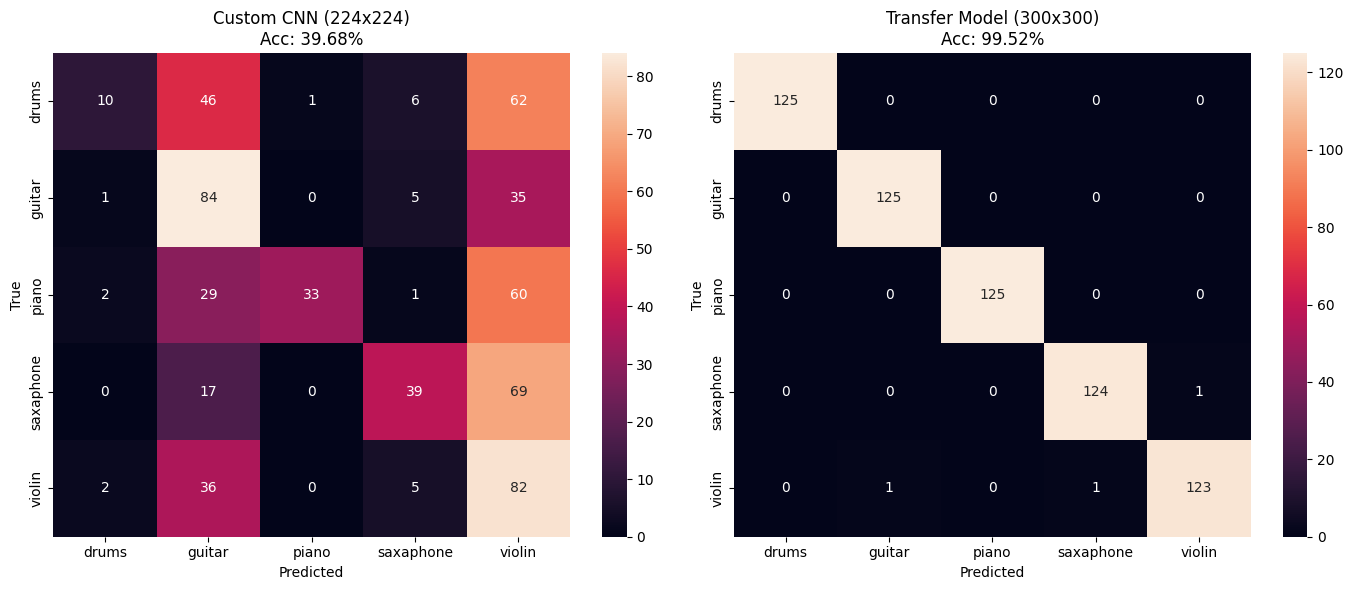

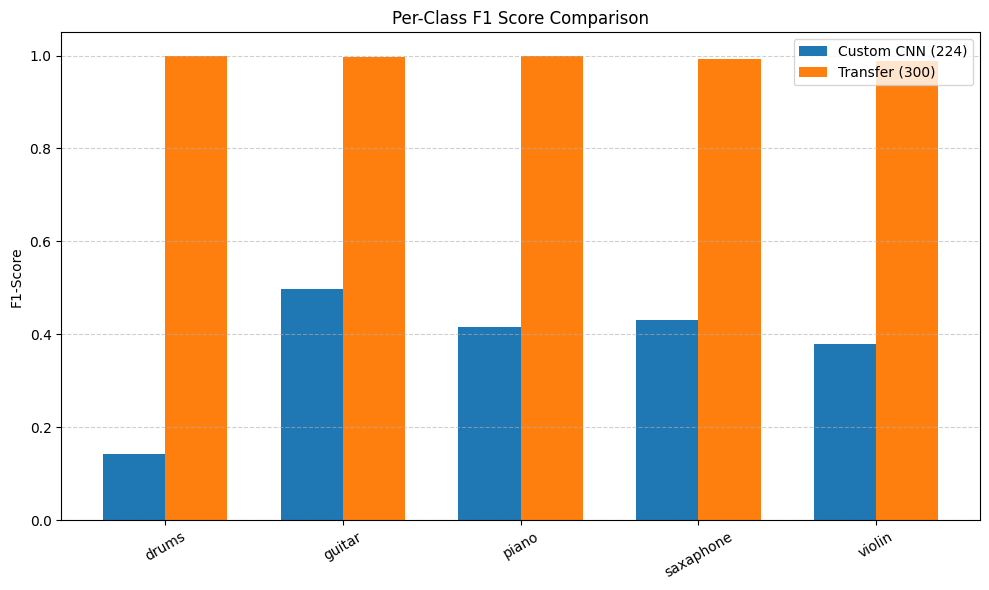

In [250]:
BATCH_SIZE = 16

CUSTOM_MODEL_PATH   = './models/musical_instruments_model_trained_best1.keras'
TRANSFER_MODEL_PATH = './models/effnetv2s_phase1.keras'

VAL_DIR = './dataset/resized_images/validation'

# ============================================================
# LOAD MODELS
# ============================================================

print("\nLoading models...")

custom_model   = tf.keras.models.load_model(CUSTOM_MODEL_PATH)
transfer_model = tf.keras.models.load_model(TRANSFER_MODEL_PATH)

print("Models loaded successfully.\n")

print("Custom model input:", custom_model.input_shape)
print("Transfer model input:", transfer_model.input_shape)


# Recreate the validation generator for better understanding and comparison

# --- Custom CNN (224x224) ---
val_gen_224 = tf.keras.preprocessing.image.ImageDataGenerator().flow_from_directory(
    VAL_DIR,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# --- Transfer Model (300x300) ---
val_gen_300 = tf.keras.preprocessing.image.ImageDataGenerator().flow_from_directory(
    VAL_DIR,
    target_size=(300, 300),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_labels = list(val_gen_224.class_indices.keys())
y_true = val_gen_224.classes


# EVALUATE
print("\nEvaluating Custom CNN (224x224)...")
custom_loss, custom_acc = custom_model.evaluate(val_gen_224, verbose=1)

print("\nEvaluating Transfer Model (300x300)...")
transfer_loss, transfer_acc = transfer_model.evaluate(val_gen_300, verbose=1)

print("\n==============================")
print(f"Custom CNN      → {custom_acc*100:.2f}%")
print(f"Transfer Model  → {transfer_acc*100:.2f}%")
print("==============================\n")


# PREDICTIONS
val_gen_224.reset()
y_pred_custom = np.argmax(custom_model.predict(val_gen_224, verbose=1), axis=1)

val_gen_300.reset()
y_pred_transfer = np.argmax(transfer_model.predict(val_gen_300, verbose=1), axis=1)


# CLASSIFICATION REPORTS
print("\n" + "="*70)
print("CLASSIFICATION REPORT - CUSTOM CNN")
print("="*70)
print(classification_report(y_true, y_pred_custom,
                            target_names=class_labels,
                            digits=4))

print("\n" + "="*70)
print("CLASSIFICATION REPORT - TRANSFER LEARNING")
print("="*70)
print(classification_report(y_true, y_pred_transfer,
                            target_names=class_labels,
                            digits=4))


# CONFUSION MATRIX
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

cm_custom = confusion_matrix(y_true, y_pred_custom)
sns.heatmap(cm_custom, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels,
            ax=ax1)
ax1.set_title(f'Custom CNN (224x224)\nAcc: {custom_acc*100:.2f}%')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')

cm_transfer = confusion_matrix(y_true, y_pred_transfer)
sns.heatmap(cm_transfer, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels,
            ax=ax2)
ax2.set_title(f'Transfer Model (300x300)\nAcc: {transfer_acc*100:.2f}%')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')

plt.tight_layout()
plt.show()


# F1 COMPARISON PER-CLASS 
f1_custom   = f1_score(y_true, y_pred_custom, average=None)
f1_transfer = f1_score(y_true, y_pred_transfer, average=None)

x = np.arange(len(class_labels))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, f1_custom, width, label='Custom CNN (224)')
plt.bar(x + width/2, f1_transfer, width, label='Transfer (300)')

plt.xticks(x, class_labels, rotation=30)
plt.ylabel('F1-Score')
plt.title('Per-Class F1 Score Comparison')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Found 125 images belonging to 5 classes.
Found 125 images belonging to 5 classes.

Predicting with Transfer Model (300x300)...
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 649ms/step
Transfer Model Test Accuracy: 1.0000 (100.00%)

Transfer Model Classification Report:
              precision    recall  f1-score   support

       drums       1.00      1.00      1.00        25
      guitar       1.00      1.00      1.00        25
       piano       1.00      1.00      1.00        25
   saxaphone       1.00      1.00      1.00        25
      violin       1.00      1.00      1.00        25

    accuracy                           1.00       125
   macro avg       1.00      1.00      1.00       125
weighted avg       1.00      1.00      1.00       125



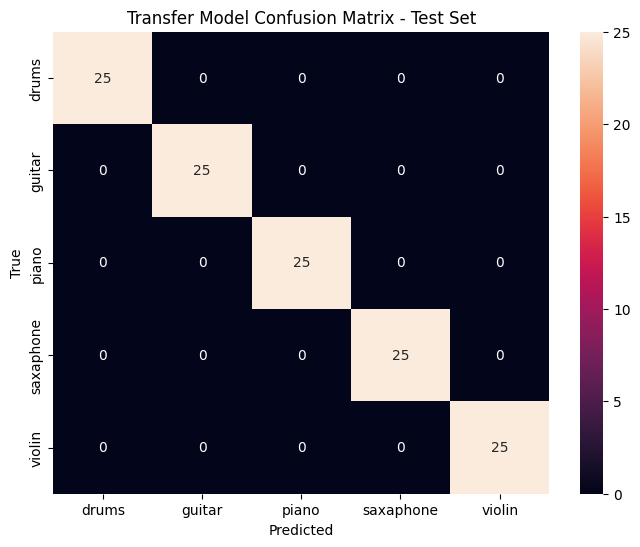


Predicting with Custom CNN (224x224)...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Custom CNN Test Accuracy: 0.8640 (86.40%)

Custom CNN Classification Report:
              precision    recall  f1-score   support

       drums       0.89      1.00      0.94        25
      guitar       0.85      0.68      0.76        25
       piano       1.00      0.84      0.91        25
   saxaphone       0.92      0.92      0.92        25
      violin       0.71      0.88      0.79        25

    accuracy                           0.86       125
   macro avg       0.87      0.86      0.86       125
weighted avg       0.87      0.86      0.86       125



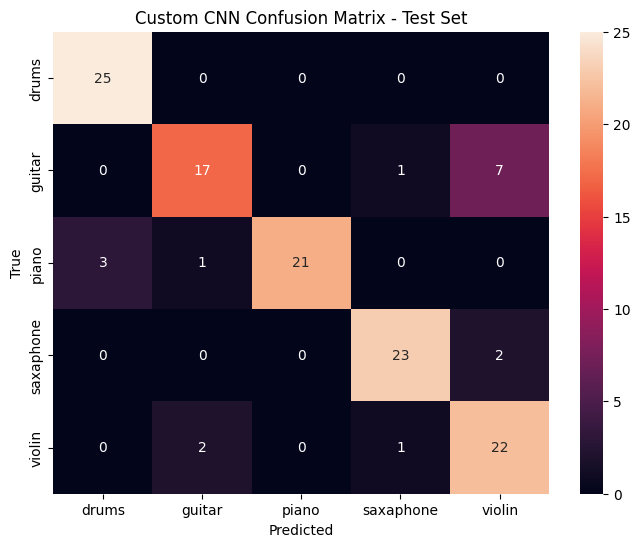

In [252]:
TEST_DIR = './dataset/resized_images/testing'

# Custom CNN → 224x224 + rescale
test_gen_224 = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    TEST_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


# Transfer Model (EfficientNetV2-S) → 300x300
test_gen_300 = tf.keras.preprocessing.image.ImageDataGenerator(
).flow_from_directory(
    TEST_DIR,
    target_size=(300, 300),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

class_names = list(test_gen_224.class_indices.keys())
true_classes = test_gen_224.classes   


# EVALUATE TRANSFER MODEL (300x300)
print("\nPredicting with Transfer Model (300x300)...")

test_gen_300.reset()
preds_transfer = transfer_model.predict(test_gen_300, verbose=1)
pred_classes_transfer = np.argmax(preds_transfer, axis=1)

transfer_accuracy = np.mean(pred_classes_transfer == true_classes)
print(f"Transfer Model Test Accuracy: {transfer_accuracy:.4f} ({transfer_accuracy*100:.2f}%)")

print("\nTransfer Model Classification Report:")
print(classification_report(true_classes, pred_classes_transfer,
                            target_names=class_names))

cm_transfer = confusion_matrix(true_classes, pred_classes_transfer)

plt.figure(figsize=(8,6))
sns.heatmap(cm_transfer, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Transfer Model Confusion Matrix - Test Set')
plt.show()

# EVALUATE CUSTOM CNN (224x224)
print("\nPredicting with Custom CNN (224x224)...")

test_gen_224.reset()
preds_custom = custom_model.predict(test_gen_224, verbose=1)
pred_classes_custom = np.argmax(preds_custom, axis=1)

custom_accuracy = np.mean(pred_classes_custom == true_classes)
print(f"Custom CNN Test Accuracy: {custom_accuracy:.4f} ({custom_accuracy*100:.2f}%)")

print("\nCustom CNN Classification Report:")
print(classification_report(true_classes, pred_classes_custom,
                            target_names=class_names))

cm_custom = confusion_matrix(true_classes, pred_classes_custom)

plt.figure(figsize=(8,6))
sns.heatmap(cm_custom, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Custom CNN Confusion Matrix - Test Set')
plt.show()

## **17.4. Evaluation of Best Trained and Best Pre-Trained Models Comparision:** ##

**From the charts above, I can infer that the best model I have for my dataset is the EffectiveNetV2 Model with a 100% accuracy.**

# **18. Image Classification API with best model:** #

In [ ]:
app = Flask(__name__, template_folder = "./template")

@app.route('/', methods=['GET'])
def index():
     return render_template('submit_image.html')

def loadmodel():
    try:
        loaded_model = models.load_model("./models/effnetv2s_phase1.keras")
        print("Loaded Model from disk")
        return loaded_model
    except Exception as e:
        print(f"Error loading model: {e}")
        return None

def prepare_image(img):
    try:
        img = Image.open(io.BytesIO(img)).convert("RGB")
        img = img.resize(target_size)
        img = np.array(img)
        print(f"Image shape after conversion: {img.shape}")
        
  
        img = img.reshape(224,224,3)
        print(f"Image shape after reshaping: {img.shape}")
        
        #convert array image data into tensor shape        
        img = np.expand_dims(img,0)  
        print(f"Image shape after expanding dims: {img.shape}")
        return img
    except Exception as e:
        print(f"Error preparing image: {e}")
        return None

def predict_result(img):
    class_names = ['drums', 'guitar', 'piano', 'saxaphone', 'violin']
    #Call load model
    model = loadmodel()
    if model is None:
        return "Model loading failed"
    try:
        #Classify the image
        probs = model.predict(img, verbose=0)[0]
        predicted_idx = np.argmax(probs)
        predicted_class = class_names[predicted_idx]
        confidence = float(probs[predicted_idx])
        
        print(f"Predicted: {predicted_class} (confidence: {confidence:.3f})")
        return predicted_class
    except Exception as e:
        print(f"Error during prediction: {e}")
        return "Prediction failed"

@app.route('/predict', methods=['POST'])
def classify_image():
    if 'imagefile' not in request.files:
        return "Please try again. The Image doesn't exist"

    #Get the image file from request.files   
    file = request.files.get("imagefile")
    if not file:
        return "No file found"
        
    #Read image into bytes        
    img_bytes = file.read()
    
    #Convert image bytes into base64 string       
    img_string = base64.b64encode(img_bytes).decode()

    #Prepare image data  
    img = prepare_image(img_bytes)
    if img is None:
        return "Image preparation failed"
    #Classify the image data    
    presult=predict_result(img)
    #Add the predicted result as a parameter in render_template    
    return render_template('submit_image.html', img_data=img_string, predict_data = presult), 200

if __name__ == '__main__':
    from werkzeug.serving import run_simple
    app.debug = True    
    run_simple('localhost', 9000, app)
    

 * Running on http://localhost:9000
Press CTRL+C to quit


# **Conclusion:**

## **19. Summary:** ##
**From all the test above, I have found that for my dataset, my best model is the the EffectiveNetV2 Small Model with the Training accuracy of 98.17%, Traning loss  of 0.0605, Validation Accuracy of 99.52%, and Validation loss of 0.0225.**

## **20. AI Reflection:** ##

***Use of GenAI:***
**For the Part B of this project I used AI as a consultant, and not as a replacement for my own independant thinking with frequent references to detailed documentations online as seen from the references below. For this project, I only used it for the use of my pre-trained models as .**

***Prompt Iteration:***
**Initial prompt 1: How do I implement and use a pretrain Image Classificaion Model in Jupyter Lab?**
**Refined and more detailed prompt 1: Explain how should I implement and use a Pre-Train Image Classificaion Model in Jupyter Lab and explain each part of the Pre-Trained Model code in detailed as I am using it for the first time.**

**Initial prompt 2: What does the info from this confusion matrix mean?**
**Refined and more detailed prompt 2: Explain in details what this confusion matrix mean and how and what I should do to improve my model's accuracy?**

**Initial prompt 3: This is my Pre-Trained model, the validation accuracy is only at 63.2%, how do I improve it?**
**Refined and more detailed prompt 3: This is my Pre-Trained model, the validation accuracy is only at 63.2%, give me suggestions on what part of the model to change to allow me to greatly improve my validation accuracy, why do you recommend me these methods, and what does it do?**

## **21. References:** ##
Dataset:
1. 1st Kaggle dataset download link: https://www.kaggle.com/datasets/nikolasgegenava/music-instruments
2. 2nd Kaggle dataset download link: https://www.kaggle.com/datasets/gpiosenka/musical-instruments-image-classification?resource=download
3. 3rd Kaggle dataset download link: https://www.kaggle.com/datasets/caahps/instrumentsdataset
4. 4th Kaggle dataset download link: https://www.kaggle.com/datasets/aayushme/music-instruments-classification
5. 5th Kaggle Drums dataset download link: https://www.kaggle.com/datasets/dimensi0n/imagenet-256?select=drum
6. 5th Kaggle Acoustic guitar dataset download link: https://www.kaggle.com/datasets/dimensi0n/imagenet-256?select=acoustic_guitar
7. 5th Kaggle Electric guitar dataset download link: https://www.kaggle.com/datasets/dimensi0n/imagenet-256?select=electric_guitar
8. 5th Kaggle Grand Piano dataset download link: https://www.kaggle.com/datasets/dimensi0n/imagenet-256?select=grand_piano
9. 5th Kaggle Saxaphone dataset download link: https://www.kaggle.com/datasets/dimensi0n/imagenet-256?select=sax
10. 5th Kaggle Violin dataset download link: https://www.kaggle.com/datasets/dimensi0n/imagenet-256?select=violin

Main Documentation References:
1. TP AIML Reference Material
2. TP AIML Lecture Slides
3. Import os reference: https://www.w3schools.com/python/module_os.asp
4. Importing of Pre-trained Models: https://www.tensorflow.org/api_docs/python/tf/keras/applications
5. Transfer Learning info: https://keras.io/guides/transfer_learning/
6. Callback: https://www.tensorflow.org/api_docs/python/tf/keras/callbacks
7. Callback & Early Stopping: https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping
8. Callback & Model Checkpoint: https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint
9. Model.fit: https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit
10. Batch Normalisation: http://tensorflow.org/api_docs/python/tf/keras/layers/BatchNormalization